# Clasificación de Cáncer de Mama — Machine Learning Estadístico
## Aprendizaje Automático Estadístico · MCDA-B Deber Semana 2

**Asignatura:** Aprendizaje automático estadístico MIA-B
**Docente:** Ivan Danilo Garcia Santillan
**Universidad:** UIDE
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico · Semana 2 · Tarea G1](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Semana%202/Tarea%20G1)

---

## 1. Descripción del Problema

**Problema:** Clasificación automática de tumores de mama en **Malignos (1)** o **Benignos (0)** a partir de características morfológicas extraídas de imágenes digitales de biopsias de tejido mamario (Fine Needle Aspirate, FNA).

**Justificación del enfoque:**
Cada muestra está descrita por mediciones numéricas del núcleo celular. Se busca aprender un límite de decisión que separe ambas clases con la mayor precisión posible. Los algoritmos seleccionados en esta semana son:

- **Árbol de Decisión:** Modelo basado en reglas jerárquicas (splits) que segmenta el espacio de variables; altamente interpretable y permite visualizar directamente la lógica de decisión.
- **Bosque Aleatorio (Random Forest):** Ensamble de múltiples árboles de decisión entrenados sobre submuestras aleatorias (bagging); reduce la varianza y el sobreajuste propios de un árbol individual.
- **SVM (Support Vector Machine):** Busca el hiperplano que maximiza el margen entre clases; eficaz en espacios de alta dimensionalidad y robusto frente a relaciones no lineales cuando se usan kernels.
- **Red Neuronal Artificial (RNA):** Perceptrón multicapa (MLP) que aprende representaciones no lineales mediante retropropagación; capaz de modelar interacciones complejas entre variables.

**Contexto clínico:** Un diagnóstico erróneo tiene consecuencias críticas. Un **falso negativo** (maligno clasificado como benigno) es más costoso que un falso positivo, por lo que se priorizará el **Recall de la clase maligna** y la **Tasa de Falsos Negativos (FNR)** como métricas clave además del accuracy general.

---

## 2. Información del Dataset

| Atributo | Detalle |
|----------|---------|
| Fuente | UCI Machine Learning Repository |
| Año | 1995 — Dr. William H. Wolberg, Universidad de Wisconsin |
| Instancias | 569 mujeres |
| Variables | 32 (ID + diagnosis + 30 features numéricas) |
| Clases | Benigno: 357 (62.7%) · Maligno: 212 (37.3%) |
| Valores perdidos | Ninguno |
| Tipo de tarea | Clasificación binaria supervisada |

---

## 3. Diccionario de Variables

Las 30 variables numéricas se obtienen calculando **3 estadísticos** sobre las mediciones de los núcleos celulares presentes en cada imagen:

| Sufijo | Descripción |
|--------|-------------|
| `_mean` | Valor promedio de la característica en todos los núcleos de la imagen |
| `_se` | Error estándar (variabilidad de la medición) |
| `_worst` | Peor valor observado (media de los 3 núcleos más grandes) |

### 3.1 Variable Objetivo

| Variable | Tipo | Descripción | Codificación |
|----------|------|-------------|--------------|
| `diagnosis` | Categórica binaria | Diagnóstico del tumor | `1` = Maligno · `0` = Benigno |


# Fase 1
## Cargar librerias

In [10]:
# Instalación (solo si no tienes ucimlrepo)
# !pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras para la Red Neuronal Artificial (Fase II)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Configuración visual general
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
tf.random.set_seed(101699)

## Primera visualización de la data

In [11]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset UCI ID=17
breast_cancer = fetch_ucirepo(id=17)

# Features y target
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets.copy()

# Vista rápida
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeras filas de y:")
display(y.head())

Shape X: (569, 30)
Shape y: (569, 1)

Primeras filas de X:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeras filas de y:


,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Revisión de la variable dependiente

In [12]:
# Unir features y target en un solo DataFrame
df = pd.concat([y, X], axis=1)

# Renombrar la columna target (suele llamarse 'Diagnosis')
df.rename(columns={df.columns[0]: 'diagnosis'}, inplace=True)

# Sustituir M=1 (Maligno) y B=0 (Benigno)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Verificar resultado
print("Distribución de clases:")
print(df['diagnosis'].value_counts())
print("\nDtypes:")
print(df.dtypes.head(10))

Distribución de clases:
diagnosis
0    357
1    212
Name: count, dtype: int64

Dtypes:
diagnosis            int64
radius1            float64
texture1           float64
perimeter1         float64
area1              float64
smoothness1        float64
compactness1       float64
concavity1         float64
concave_points1    float64
symmetry1          float64
dtype: object


In [13]:
# Tabla de valores perdidos
missing = pd.DataFrame({
    'Variable'   : df.columns,
    'Tipo'       : df.dtypes.values,
    'N_Missing'  : df.isnull().sum().values,
    'Pct_Missing': (df.isnull().mean() * 100).round(2).values
})

missing = missing[missing['N_Missing'] > 0]

if missing.empty:
    print("No se encontraron valores perdidos en el dataset.")
else:
    print("Variables con valores perdidos:")
    display(missing)

No se encontraron valores perdidos en el dataset.


## Resumen estadístico

In [14]:
# Solo variables numéricas (excluye diagnosis)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

summary = df[num_cols].agg([
    'count', 'mean', 'std', 'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max'
]).T

summary.columns = ['N', 'Media', 'SD', 'Min', 'Q1', 'Mediana', 'Q3', 'Max']

# Agregar % de NA
summary['N_NA']    = df[num_cols].isnull().sum().values
summary['Pct_NA']  = (df[num_cols].isnull().mean() * 100).round(2).values

summary = summary.round(4)
print("=== Resumen Estadístico ===")
display(summary)

=== Resumen Estadístico ===


,N,Media,SD,Min,Q1,Mediana,Q3,Max,N_NA,Pct_NA
radius1,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100,0,0.0
texture1,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800,0,0.0
perimeter1,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000,0,0.0
area1,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000,0,0.0
smoothness1,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634,0,0.0
compactness1,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454,0,0.0
concavity1,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268,0,0.0
concave_points1,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012,0,0.0
symmetry1,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040,0,0.0
fractal_dimension1,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974,0,0.0


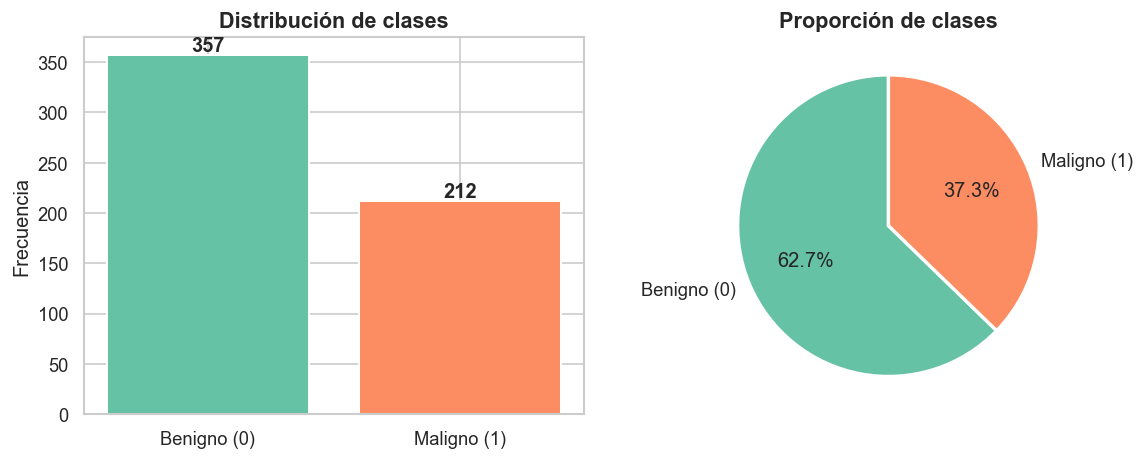

In [15]:
##  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo
counts = df['diagnosis'].value_counts()
labels = ['Benigno (0)', 'Maligno (1)']
colors = ['#66C2A5', '#FC8D62']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(
    counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_distribucion_clases.png', bbox_inches='tight')
plt.show()

## Interpretación

La variable objetivo presenta una distribución moderadamente desbalanceada: 357 casos benignos (62,7%) frente a 212 malignos (37,3%). El desbalance es comparable al del Titanic, y aunque no requiere técnicas de rebalanceo agresivo (como SMOTE), sí justifica que la evaluación del rendimiento se realice priorizando métricas sensibles a la clase maligna —especialmente Recall y FNR— sobre el Accuracy global, dado el mayor costo clínico de un falso negativo en diagnóstico oncológico.

# Fase 2
## Análisis exploratorio

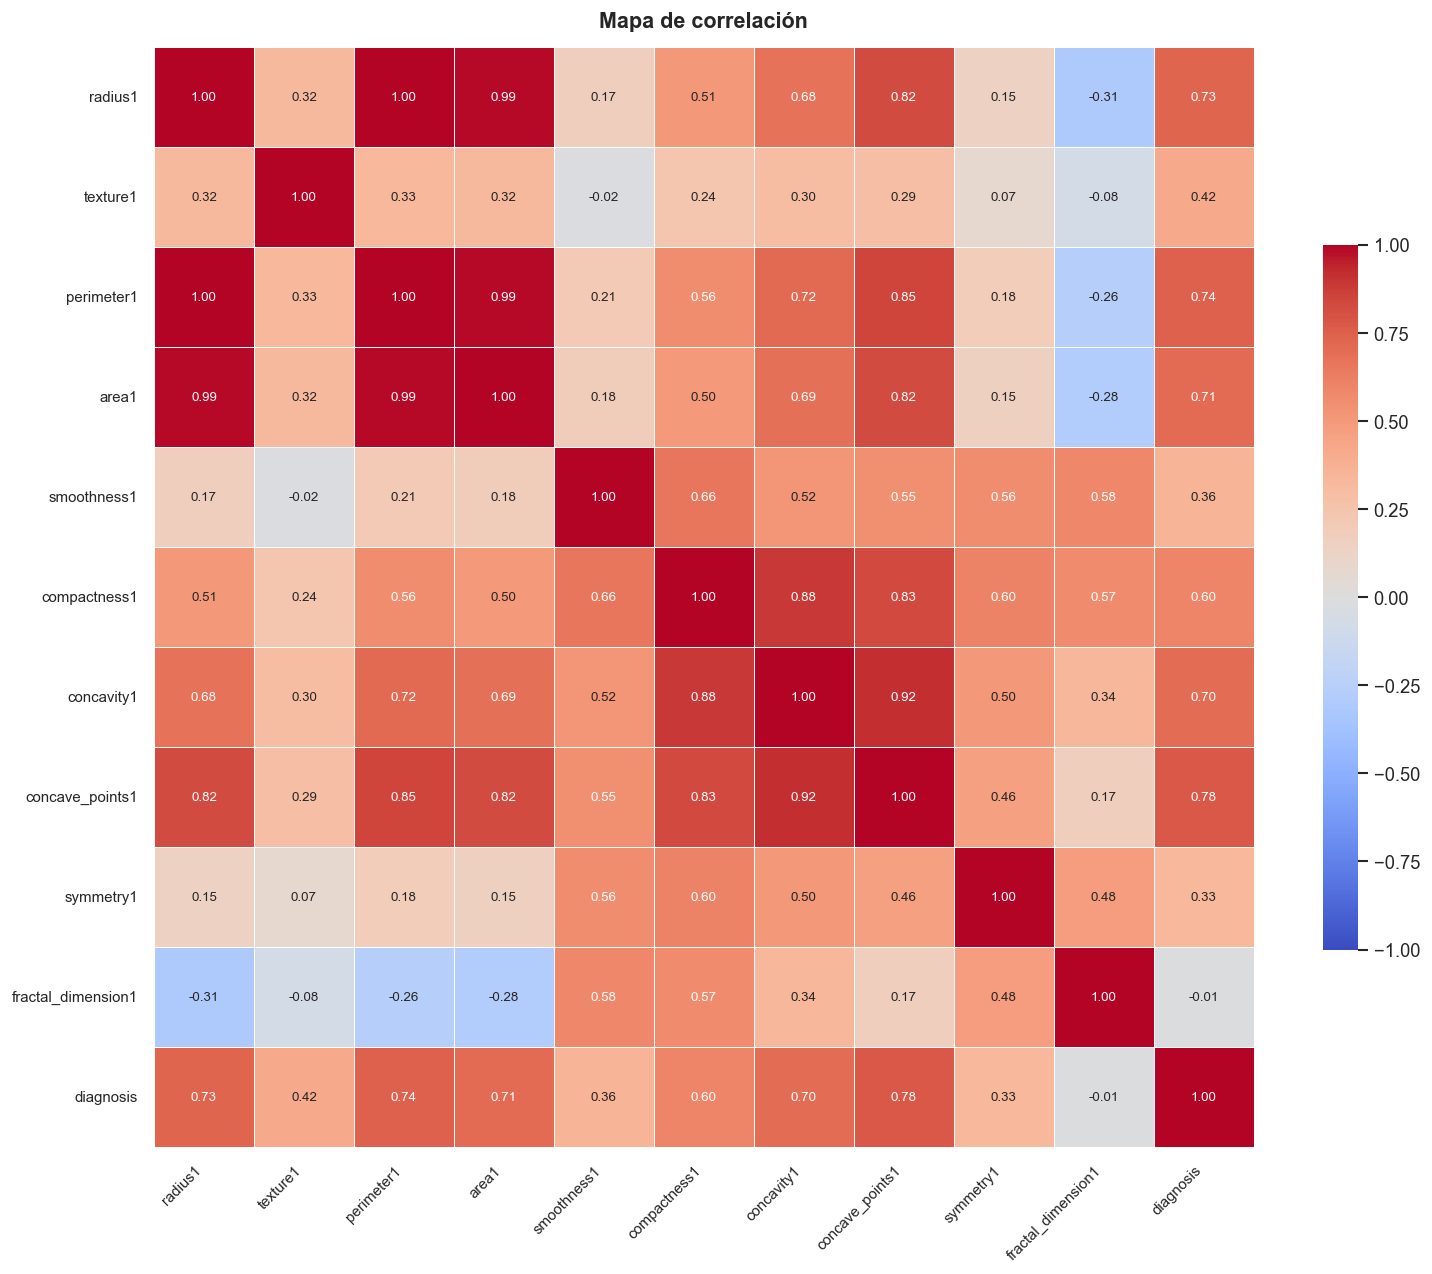

In [16]:
# Tomar TODAS las variables numéricas excepto diagnosis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'diagnosis']

# Usar todas para correlación (o las primeras 10 para que quepa bien)
cols_corr = num_cols[:10]   # ajusta este número según lo que imprima el diagnóstico

corr = df[cols_corr + ['diagnosis']].corr()

fig, ax = plt.subplots(figsize=(13, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'shrink': 0.6}
)

ax.set_title('Mapa de correlación', fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig_correlacion.png', bbox_inches='tight')
plt.show()

### Interpretación

El dataset contiene **30 variables numéricas** organizadas en 3 grupos según el tipo de medición estadística aplicada a cada característica extraída de las imágenes de biopsia. Para el análisis exploratorio se trabajó con las **10 variables _mean** (sufijo `1` en este dataset), que representan el valor promedio de cada característica por muestra.

### Variables de Tamaño — Geometría del Núcleo

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 1 | **radius** | `radius1` | `radius2` | `radius3` | Distancia promedio del centro a los puntos del perímetro del núcleo celular (µm) |
| 2 | **perimeter** | `perimeter1` | `perimeter2` | `perimeter3` | Longitud total del contorno del núcleo celular (µm) |
| 3 | **area** | `area1` | `area2` | `area3` | Superficie total del núcleo celular (µm²). Altamente colineal con radius y perimeter (r > 0.99) |

### Variables de Forma e Irregularidad del Contorno

| # | Variable base | _mean | _se | _worst | Descripción |
|---|--------------|-------|-----|--------|-------------|
| 4 | **concavity** | `concavity1` | `concavity2` | `concavity3` | Severidad de las porciones cóncavas del contorno del núcleo |
| 5 | **concave points** | `concave_points1` | `concave_points2` | `concave_points3` | Número de puntos cóncavos en el contorno; **predictor más fuerte de malignidad** (r = 0.78 con diagnosis) |
| 6 | **compactness** | `compactness1` | `compactness2` | `compactness3` | Calculada como (perímetro² / área) − 1; valores altos indican formas irregulares y poco circulares |

### Otras variables relevantes

| # | Variable base | _mean | Descripción |
|---|--------------|-------|-------------|
| 7 | **texture** | `texture1` | Heterogeneidad de la superficie celular |
| 8 | **smoothness** | `smoothness1` | Variación local del radio (suavidad del contorno) |
| 9 | **symmetry** | `symmetry1` | Simetría del núcleo respecto a su eje mayor |
| 10 | **fractal dimension** | `fractal_dimension1` | Complejidad fractal del contorno; correlación casi nula con diagnosis (r = −0.01) |

---

## Correlación con el Diagnóstico — Ranking

| Ranking | Variable | Correlación con `diagnosis` | Interpretación |
|---------|----------|-----------------------------|----------------|
| 1 | `concave_points1` | **0.78** | Muy alta — mejor predictor individual |
| 2 | `perimeter1` | **0.74** | Muy alta — tamaño del tumor |
| 3 | `radius1` | **0.73** | Muy alta — tamaño del tumor |
| 4 | `area1` | 0.71 | Alta — colineal con radio y perímetro |
| 5 | `concavity1` | 0.70 | Alta — irregularidad del contorno |
| 6 | `compactness1` | 0.60 | Moderada |
| 7 | `texture1` | 0.42 | Moderada |
| 8 | `smoothness1` | 0.36 | Baja-moderada |
| 9 | `symmetry1` | 0.33 | Baja |
| 10 | `fractal_dimension1` | **-0.01** | Nula — candidata a descarte |

---

## Notas Metodológicas Previas al Modelado

> **Multicolinealidad:** `radius`, `perimeter` y `area` presentan correlaciones superiores a **0.99** entre sí. Se conservará únicamente `area_mean` como representante del tamaño tumoral para reducir redundancia.

> **Variable candidata a descarte:** `fractal_dimension` presenta correlación prácticamente nula con el diagnóstico (r = −0.01) y será excluida de la versión final de variables.

> **Escalado de datos:** SVM y la Red Neuronal Artificial son sensibles a la escala de las variables; el Árbol de Decisión y el Bosque Aleatorio no lo son (se basan en umbrales/splits, invariantes a transformaciones monótonas). Aun así, se utilizarán las mismas variables escaladas para todos los modelos por consistencia comparativa.

> **Métrica prioritaria:** Dado el contexto clínico, se priorizará el **Recall de la clase Maligna (1)** y la **FNR** para minimizar falsos negativos, sin descuidar el balance general mediante F1-Score y AUC-ROC.

---

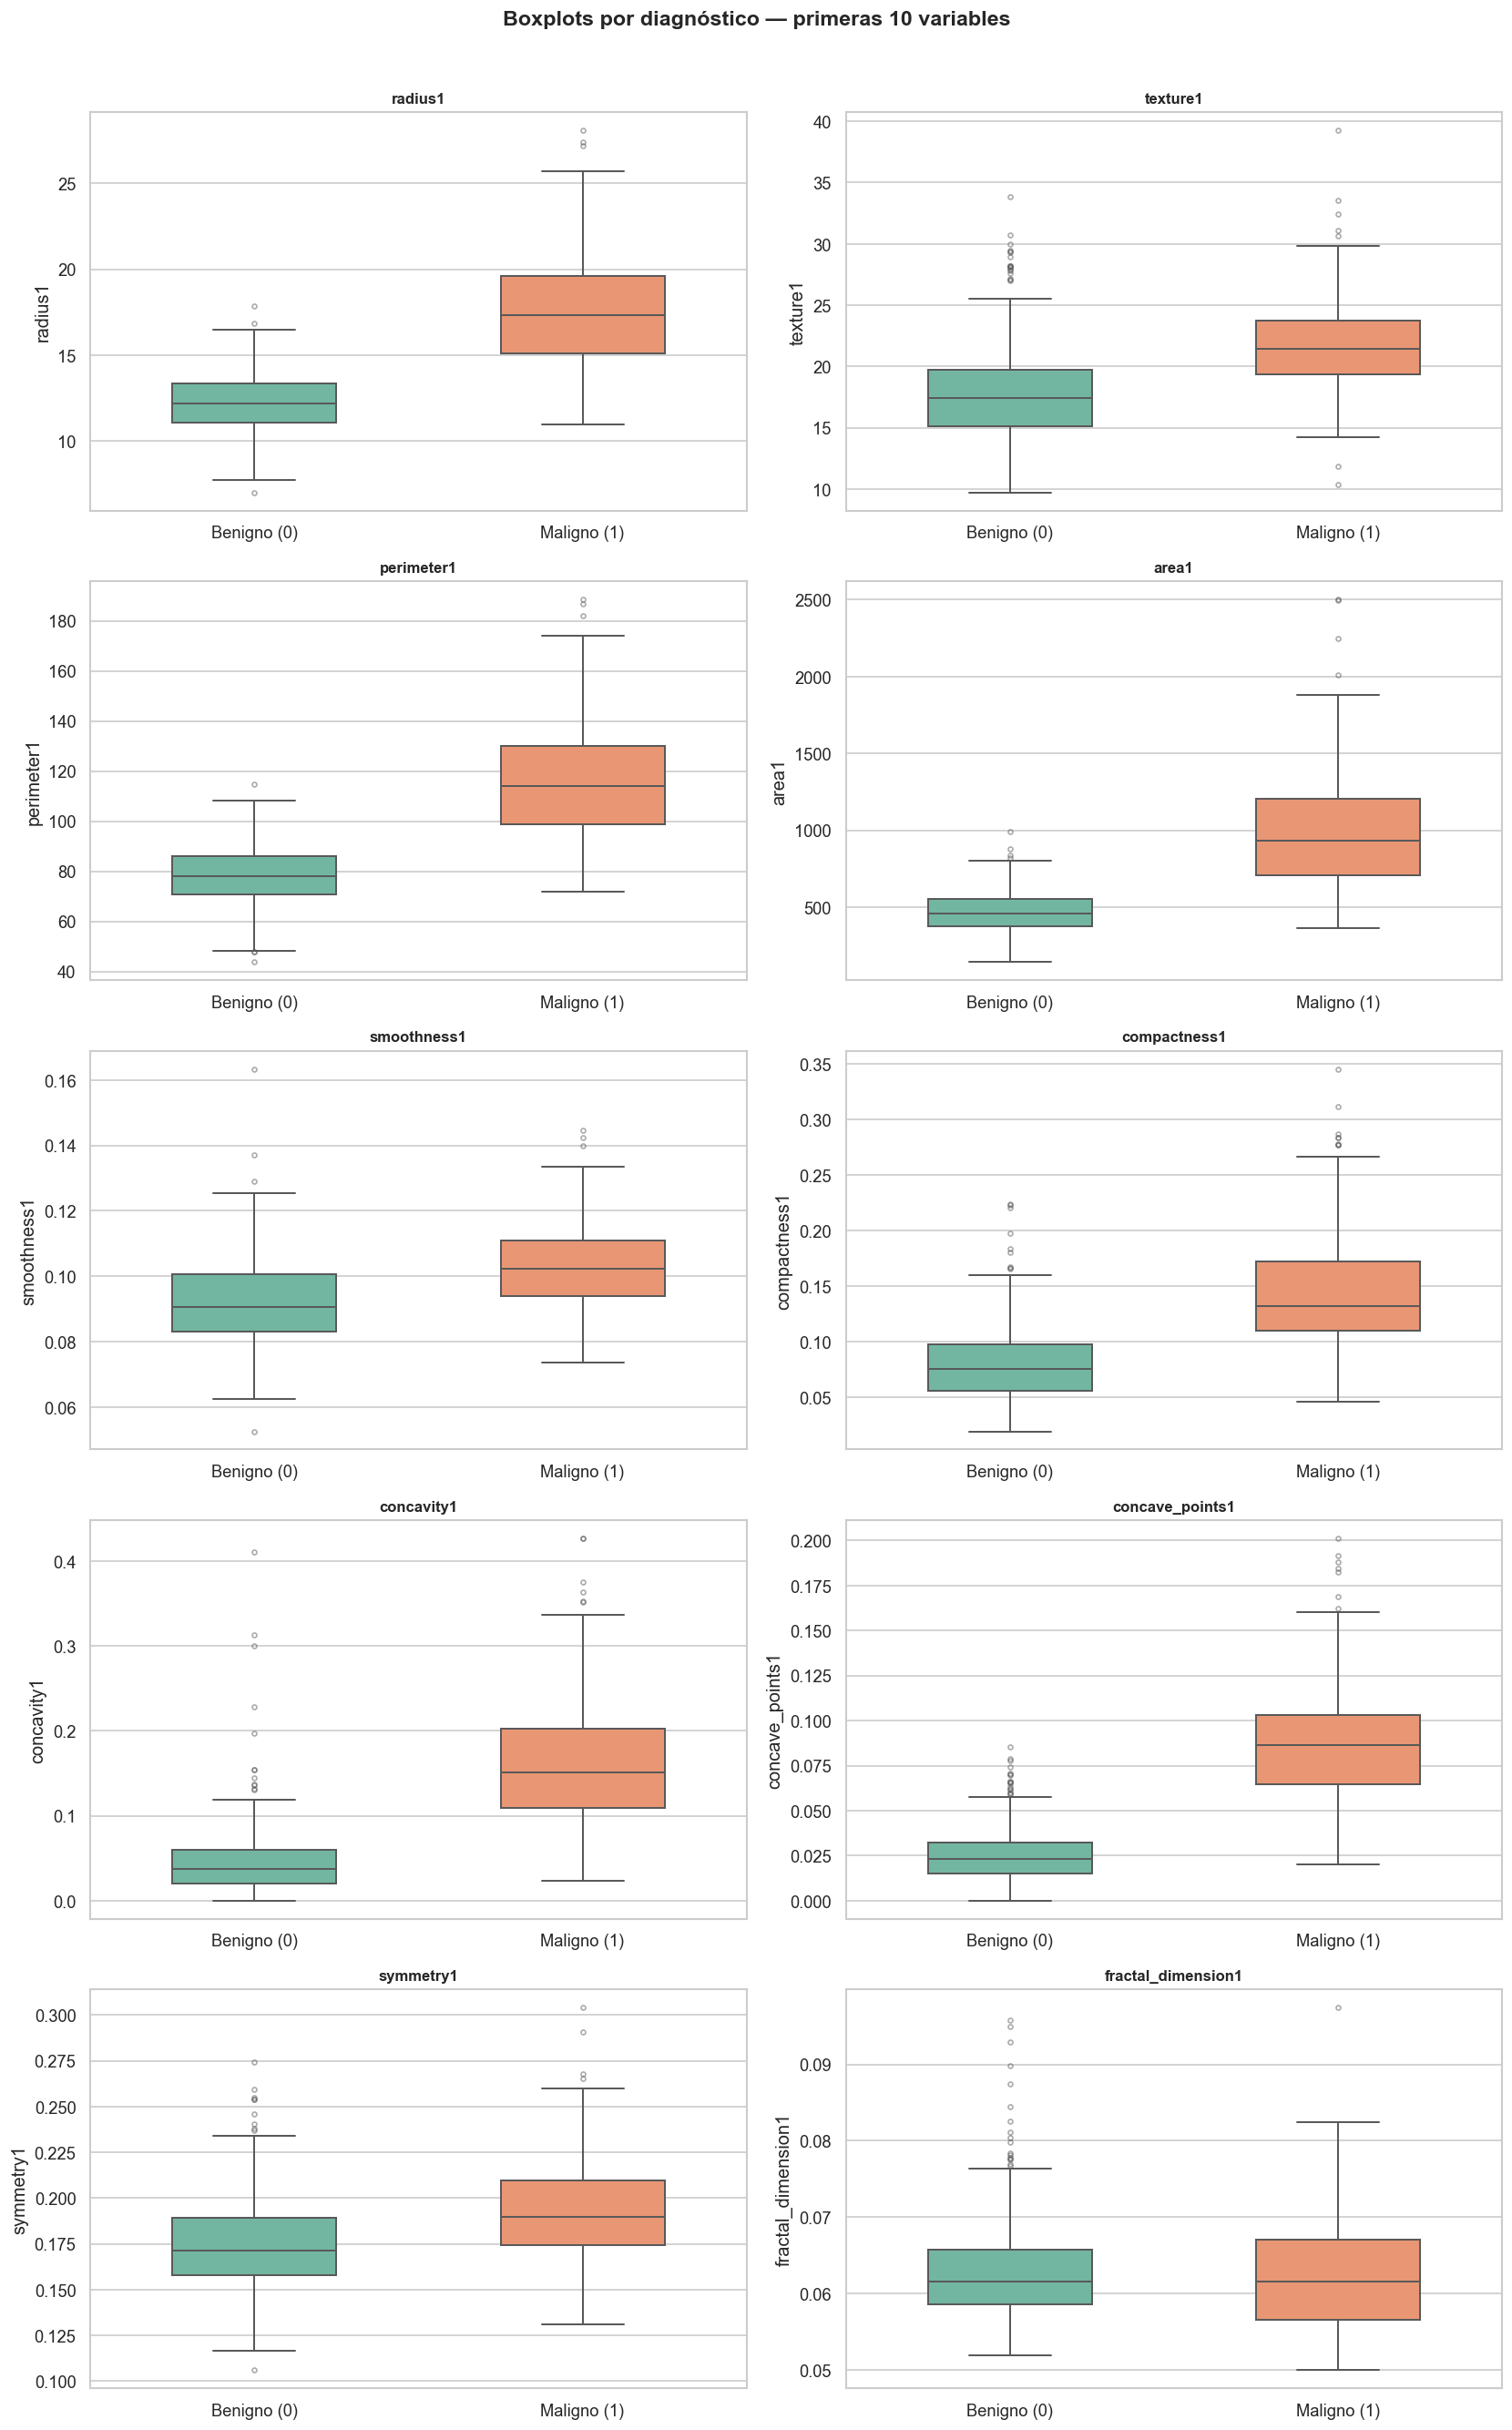

In [17]:
cols_box = num_cols[:10]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    sns.boxplot(
        data=df, x='diagnosis', y=col,
        hue='diagnosis',
        palette={0: '#66C2A5', 1: '#FC8D62'},
        legend=False,
        ax=axes[i],
        width=0.5, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Benigno (0)', 'Maligno (1)'])

for j in range(len(cols_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por diagnóstico — primeras 10 variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots.png', bbox_inches='tight')
plt.show()

## Interpretación

Los boxplots revelan diferencias claras entre tumores benignos y malignos en la mayoría de variables. Las variables de **tamaño** (`radius1`, `perimeter1`, `area1`) muestran la separación más pronunciada: los tumores malignos presentan medianas notablemente más altas y cajas más amplias. De forma similar, `concavity1` y `concave_points1` evidencian contornos significativamente más irregulares e indentados en los tumores malignos, con cajas casi sin solapamiento respecto a los benignos.

En contraste, `smoothness1` y `symmetry1` muestran diferencias más modestas entre clases. El caso más llamativo es `fractal_dimension1`: ambas clases presentan distribuciones casi idénticas, confirmando su correlación nula con el diagnóstico (r = −0.01). En cuanto a valores atípicos, `area1` presenta outliers extremos únicamente en la clase maligna (valores superiores a 2000 µm²), lo que puede afectar de forma diferenciada a cada algoritmo: fuertemente a SVM (los outliers suelen convertirse en vectores de soporte) y a la RNA (distorsionan el gradiente durante el entrenamiento), y de forma mucho más leve al Árbol de Decisión y al Bosque Aleatorio, cuyos splits son invariantes a la magnitud de los valores extremos.


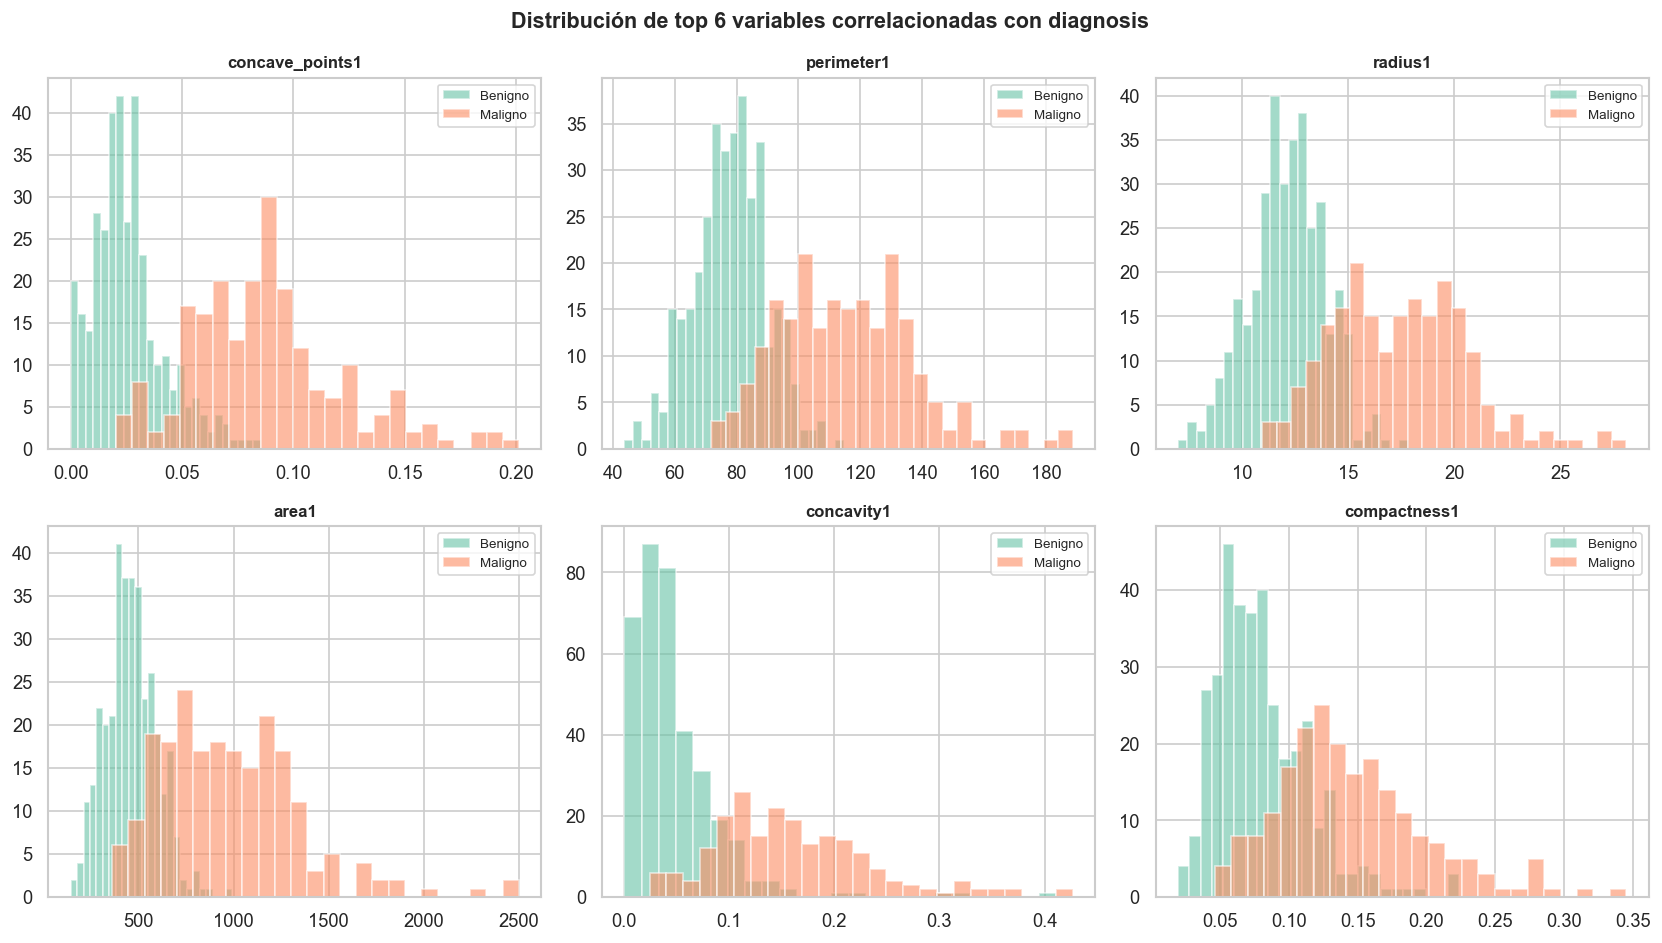

In [18]:
# Top 6 variables más correlacionadas con diagnosis
top_corr = (
    corr['diagnosis']
    .drop('diagnosis')
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_corr):
    for diag, label, color in zip([0, 1], ['Benigno', 'Maligno'], ['#66C2A5', '#FC8D62']):
        axes[i].hist(
            df[df['diagnosis'] == diag][col],
            bins=25, alpha=0.6, label=label,
            color=color, edgecolor='white'
        )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de top 6 variables correlacionadas con diagnosis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_histogramas_top.png', bbox_inches='tight')
plt.show()

## Interpretación

Los histogramas de las 6 variables más correlacionadas con el diagnóstico confirman lo observado en los boxplots. En `concave_points1`, `concavity1` y `compactness1` la distribución benigna está fuertemente concentrada cerca de cero, mientras que la maligna es más dispersa y se desplaza hacia valores altos. `perimeter1`, `radius1` y `area1` muestran un patrón similar: la clase benigna se agrupa en valores bajos, mientras que la maligna se extiende hacia la derecha con mayor dispersión.

No existe separación perfecta entre clases en ninguna variable individual — siempre hay una zona de solapamiento. Esto anticipa que ningún clasificador alcanzará 100% de accuracy con una sola variable y que la combinación de múltiples features, junto con la capacidad de cada algoritmo para construir fronteras de decisión (lineales en SVM, jerárquicas en los árboles, no lineales en la RNA), será clave para maximizar el rendimiento.


# Fase 3
## Preprocesamiento Avanzado y Modelado

### Algoritmos de esta semana

| Algoritmo | ¿Necesita escala? | Razón |
|-----------|-------------------|-------|
| Árbol de Decisión | No | Los splits se basan en umbrales por variable; invariante a transformaciones monótonas como el escalado |
| Bosque Aleatorio | No | Es un ensamble de árboles; hereda la invarianza al escalado del árbol individual |
| SVM | Sí | La maximización del margen depende de distancias entre puntos; variables con escalas distintas dominarían el cálculo |
| RNA (MLP) | Sí | El descenso de gradiente converge más rápido y estable cuando las entradas están normalizadas; evita saturación de las activaciones |

### Métodos de reescalamiento

| Método | Fórmula | Cuándo usarlo |
|--------|---------|---------------|
| **StandardScaler** | (x − μ) / σ | Cuando los datos tienen outliers moderados y distribución aproximadamente normal. **Opción principal (versión con outliers).** |
| **RobustScaler** | (x − mediana) / IQR | Cuando hay outliers severos (como `area1` con valores > 2000). Menos sensible a extremos. **Versión sin outliers.** |

Por consistencia comparativa con la semana anterior, se utilizará **StandardScaler** en la versión baseline (con outliers) y **RobustScaler** en la versión mejorada (sin outliers) para los cuatro algoritmos, incluyendo Árbol de Decisión y Bosque Aleatorio (aunque no lo requieran estrictamente, mantiene la comparación homogénea entre modelos).

### Decisiones con datos atípicos

- **Versión con outliers (baseline):** Conservamos todos los datos, aplicamos StandardScaler.
- **Versión sin outliers (mejorada):** Eliminamos filas fuera de 1.5×IQR en las variables con outliers severos, aplicamos RobustScaler.

### Ingeniería de variables

Dado que `radius1`, `perimeter1` y `area1` tienen correlación > 0.99 entre sí, se eliminan `perimeter1` y `radius1` (redundantes con `area1`) y `fractal_dimension1` (correlación nula con diagnosis).

### Afinamiento de hiperparámetros (tuning)

| Algoritmo | Método de afinamiento | Hiperparámetros explorados |
|-----------|----------------------|------------------------------|
| Árbol de Decisión | `GridSearchCV` | `max_depth`, `criterion` |
| Bosque Aleatorio | `GridSearchCV` | `n_estimators`, `max_depth` |
| SVM | `GridSearchCV` | `C`, `kernel` |
| RNA | Búsqueda manual + `EarlyStopping` | Arquitectura (capas/neuronas), `learning_rate` — no se usa CV por el costo computacional de reentrenar redes; se reemplaza por validación holdout monitoreada con `val_loss` |


In [19]:
# Semilla de reproducibilidad
SEED = 101699

In [20]:
# ── Solo las variables _mean que analizamos en Fase II
cols_mean = ['texture1', 'area1', 'smoothness1', 'compactness1',
             'concavity1', 'concave_points1', 'symmetry1']
# (excluimos radius1, perimeter1, fractal_dimension1 por las razones del EDA)

# ── Ingeniería de variables sobre esas 7
df_model = df.copy()
df_model['irregularidad'] = df_model['compactness1'] * df_model['concavity1']
df_model['forma_nuclear'] = df_model['concave_points1'] / (df_model['smoothness1'] + 1e-6)

cols_nuevas = ['irregularidad', 'forma_nuclear']

# ── Lista final: 7 originales seleccionadas + 2 nuevas = 9 variables
cols_final = cols_mean + cols_nuevas

print("Variables finales del modelo:")
for i, c in enumerate(cols_final, 1):
    print(f"  {i}. {c}")

print(f"\nTotal: {len(cols_final)} variables")
print("\nCorrelación de features nuevas con diagnosis:")
print(df_model[cols_nuevas + ['diagnosis']].corr()['diagnosis'].drop('diagnosis'))

Variables finales del modelo:
  1. texture1
  2. area1
  3. smoothness1
  4. compactness1
  5. concavity1
  6. concave_points1
  7. symmetry1
  8. irregularidad
  9. forma_nuclear

Total: 9 variables

Correlación de features nuevas con diagnosis:
irregularidad    0.585277
forma_nuclear    0.792525
Name: diagnosis, dtype: float64


In [21]:
# ── VERSIÓN 1: Con outliers
X_full = df_model[cols_final].copy()
y_full = df_model['diagnosis'].copy()

# ── VERSIÓN 2: Sin outliers (IQR sobre variables con outliers severos)
df_clean = df_model.copy()
cols_outlier = ['area1', 'compactness1', 'concavity1', 'concave_points1', 'irregularidad']

for col in cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 1.5*IQR) &
        (df_clean[col] <= Q3 + 1.5*IQR)
    ]

print(f"Filas originales : {len(df_model)}")
print(f"Tras limpiar     : {len(df_clean)}")
print(f"Eliminadas       : {len(df_model) - len(df_clean)}")
print(f"\nDistribución tras limpieza:\n{df_clean['diagnosis'].value_counts()}")

X_clean = df_clean[cols_final].copy()
y_clean = df_clean['diagnosis'].copy()

Filas originales : 569
Tras limpiar     : 484
Eliminadas       : 85

Distribución tras limpieza:
diagnosis
0    352
1    132
Name: count, dtype: int64


In [22]:
# ── Con outliers → StandardScaler
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full)

scaler_std = StandardScaler()
X_tr_f_sc  = scaler_std.fit_transform(X_tr_f)
X_te_f_sc  = scaler_std.transform(X_te_f)

# ── Sin outliers → RobustScaler
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=SEED, stratify=y_clean)

scaler_rob = RobustScaler()
X_tr_c_sc  = scaler_rob.fit_transform(X_tr_c)
X_te_c_sc  = scaler_rob.transform(X_te_c)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Train con outliers : {X_tr_f_sc.shape}")
print(f"Train sin outliers : {X_tr_c_sc.shape}")

Train con outliers : (455, 9)
Train sin outliers : (387, 9)


In [23]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, ax_cm, ax_roc, usar_cv=True):

    # Validación cruzada sobre train
    if usar_cv:
        cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
    else:
        cv_mean, cv_std = np.nan, np.nan

    # Entrenamiento final
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    # Métricas
    acc_train = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_test  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba)
    cm        = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision   = TP / (TP + FP)
    recall      = TP / (TP + FN)
    f1          = 2 * precision * recall / (precision + recall)
    especif     = TN / (TN + FP)
    fnr         = FN / (FN + TP)

    # Detección de sobreajuste
    gap    = acc_train - acc_test
    estado = "Sin sobreajuste" if gap < 0.03 else "Posible sobreajuste"

    print(f"\n{'='*52}")
    print(f"  {nombre}")
    print(f"{'='*52}")
    if usar_cv:
        print(f"  CV Accuracy (5-fold) : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  Train Accuracy       : {acc_train:.4f}")
    print(f"  Test  Accuracy       : {acc_test:.4f}  ({estado}, gap={gap:.4f})")
    print(f"\n  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  Especificidad: {especif:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  FNR          : {fnr:.4f}  ← % malignos NO detectados")

    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Benigno', 'Maligno'],
        colorbar=False, ax=ax_cm, cmap='Blues'
    )
    ax_cm.set_title(f'Conf. Matrix\n{nombre}', fontsize=8, fontweight='bold')

    # Curva ROC
    fpr_c, tpr_c, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr_c, tpr_c, lw=2, label=f'AUC={auc:.3f}')
    ax_roc.plot([0,1],[0,1],'k--', lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC\n{nombre}', fontsize=8, fontweight='bold')
    ax_roc.legend(fontsize=8)

    return {
        'Modelo'    : nombre,
        'CV Acc %'  : round(cv_mean*100, 2) if usar_cv else np.nan,
        'Train Acc %': round(acc_train*100, 2),
        'Test Acc %' : round(acc_test*100, 2),
        'Precision %': round(precision*100, 2),
        'Recall %'   : round(recall*100, 2),
        'Especif. %' : round(especif*100, 2),
        'F1 %'       : round(f1*100, 2),
        'AUC %'      : round(auc*100, 2),
        'FNR %'      : round(fnr*100, 2),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN
    }

### Árbol de Decisión


=====================ARBOL DE DECISION======================

  DT — Baseline (con outliers, max_depth=4)
  CV Accuracy (5-fold) : 0.9319 ± 0.0213
  Train Accuracy       : 0.9758
  Test  Accuracy       : 0.8947  (Posible sobreajuste, gap=0.0811)

  TP=37  TN=65  FP=7  FN=5
  Precision    : 0.8409
  Recall       : 0.8810
  Especificidad: 0.9028
  F1-Score     : 0.8605
  AUC-ROC      : 0.9294
  FNR          : 0.1190  ← % malignos NO detectados

Mejores hiperparámetros DT: {'criterion': 'gini', 'max_depth': 4}

  DT — Mejorado (sin outliers, depth=4, gini)
  CV Accuracy (5-fold) : 0.9043 ± 0.0524
  Train Accuracy       : 0.9690
  Test  Accuracy       : 0.9588  (Sin sobreajuste, gap=0.0102)

  TP=24  TN=69  FP=2  FN=2
  Precision    : 0.9231
  Recall       : 0.9231
  Especificidad: 0.9718
  F1-Score     : 0.9231
  AUC-ROC      : 0.9266
  FNR          : 0.0769  ← % malignos NO detectados


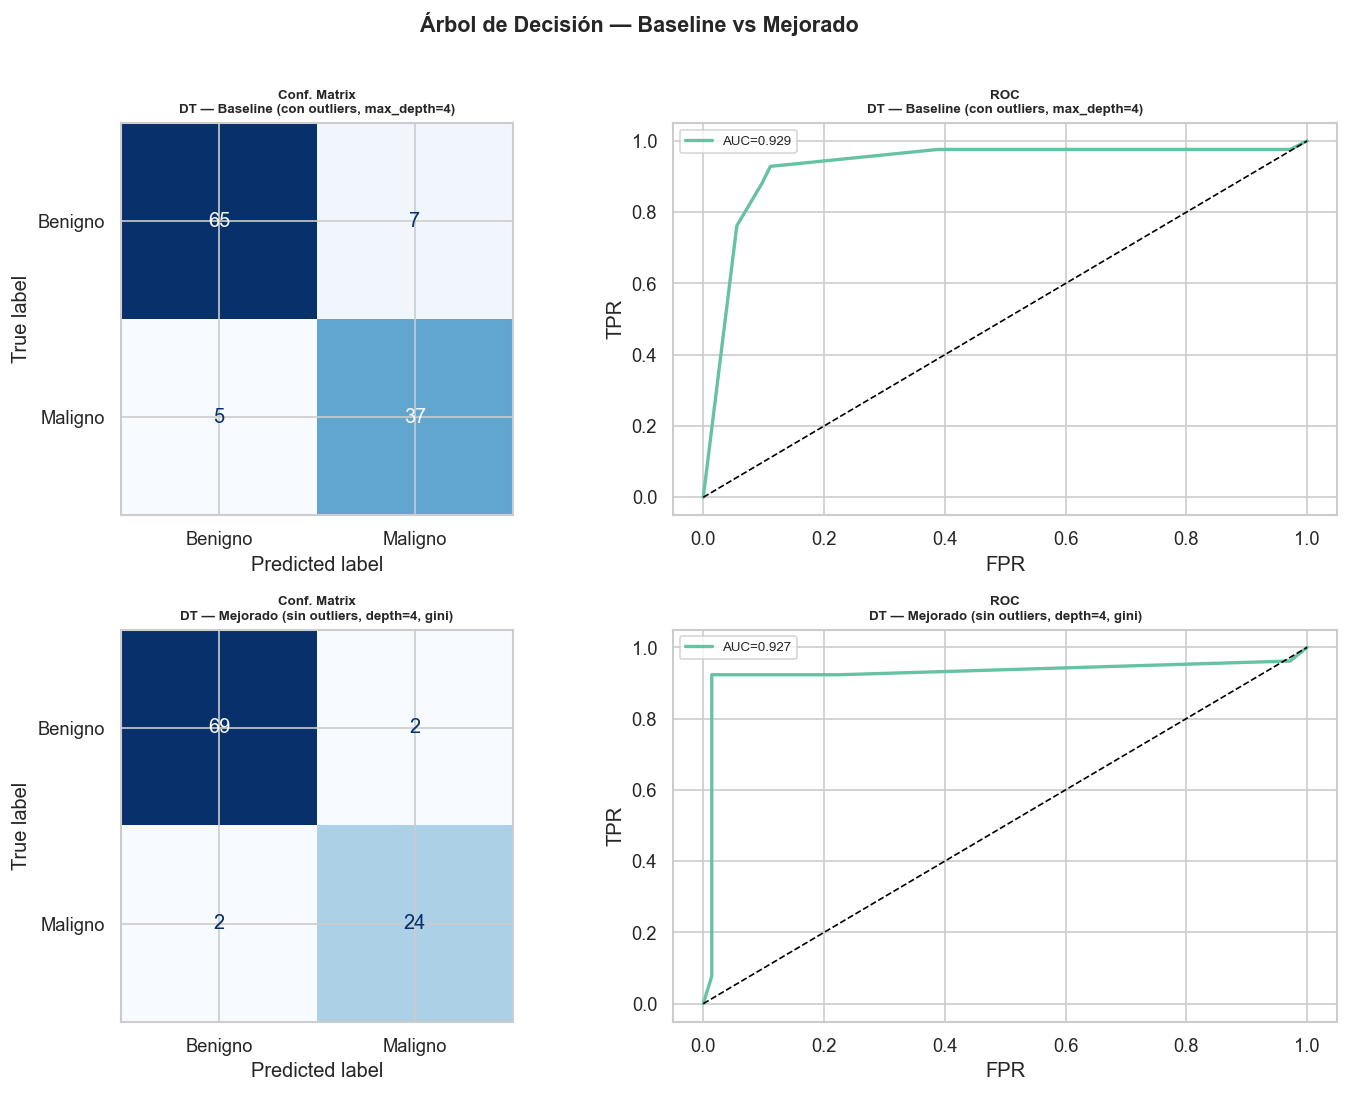

In [24]:
print("\n" + "ARBOL DE DECISION".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers) — replica los hiperparámetros de "decision_tree_2.py"
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
res_dt_base = evaluar_modelo(
    "DT — Baseline (con outliers, max_depth=4)", dt_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado: GridSearchCV sobre max_depth y criterion, sin outliers
param_grid_dt = {'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                  'criterion': ['gini', 'entropy']}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=SEED), param_grid_dt,
                      cv=cv, scoring='accuracy', n_jobs=-1)
dt_gs.fit(X_tr_c_sc, y_tr_c)
print(f"\nMejores hiperparámetros DT: {dt_gs.best_params_}")
dt_mejor = dt_gs.best_estimator_

res_dt_mejor = evaluar_modelo(
    f"DT — Mejorado (sin outliers, depth={dt_gs.best_params_['max_depth']}, {dt_gs.best_params_['criterion']})",
    dt_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Árbol de Decisión — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_dt_resultados.png', bbox_inches='tight')
plt.show()

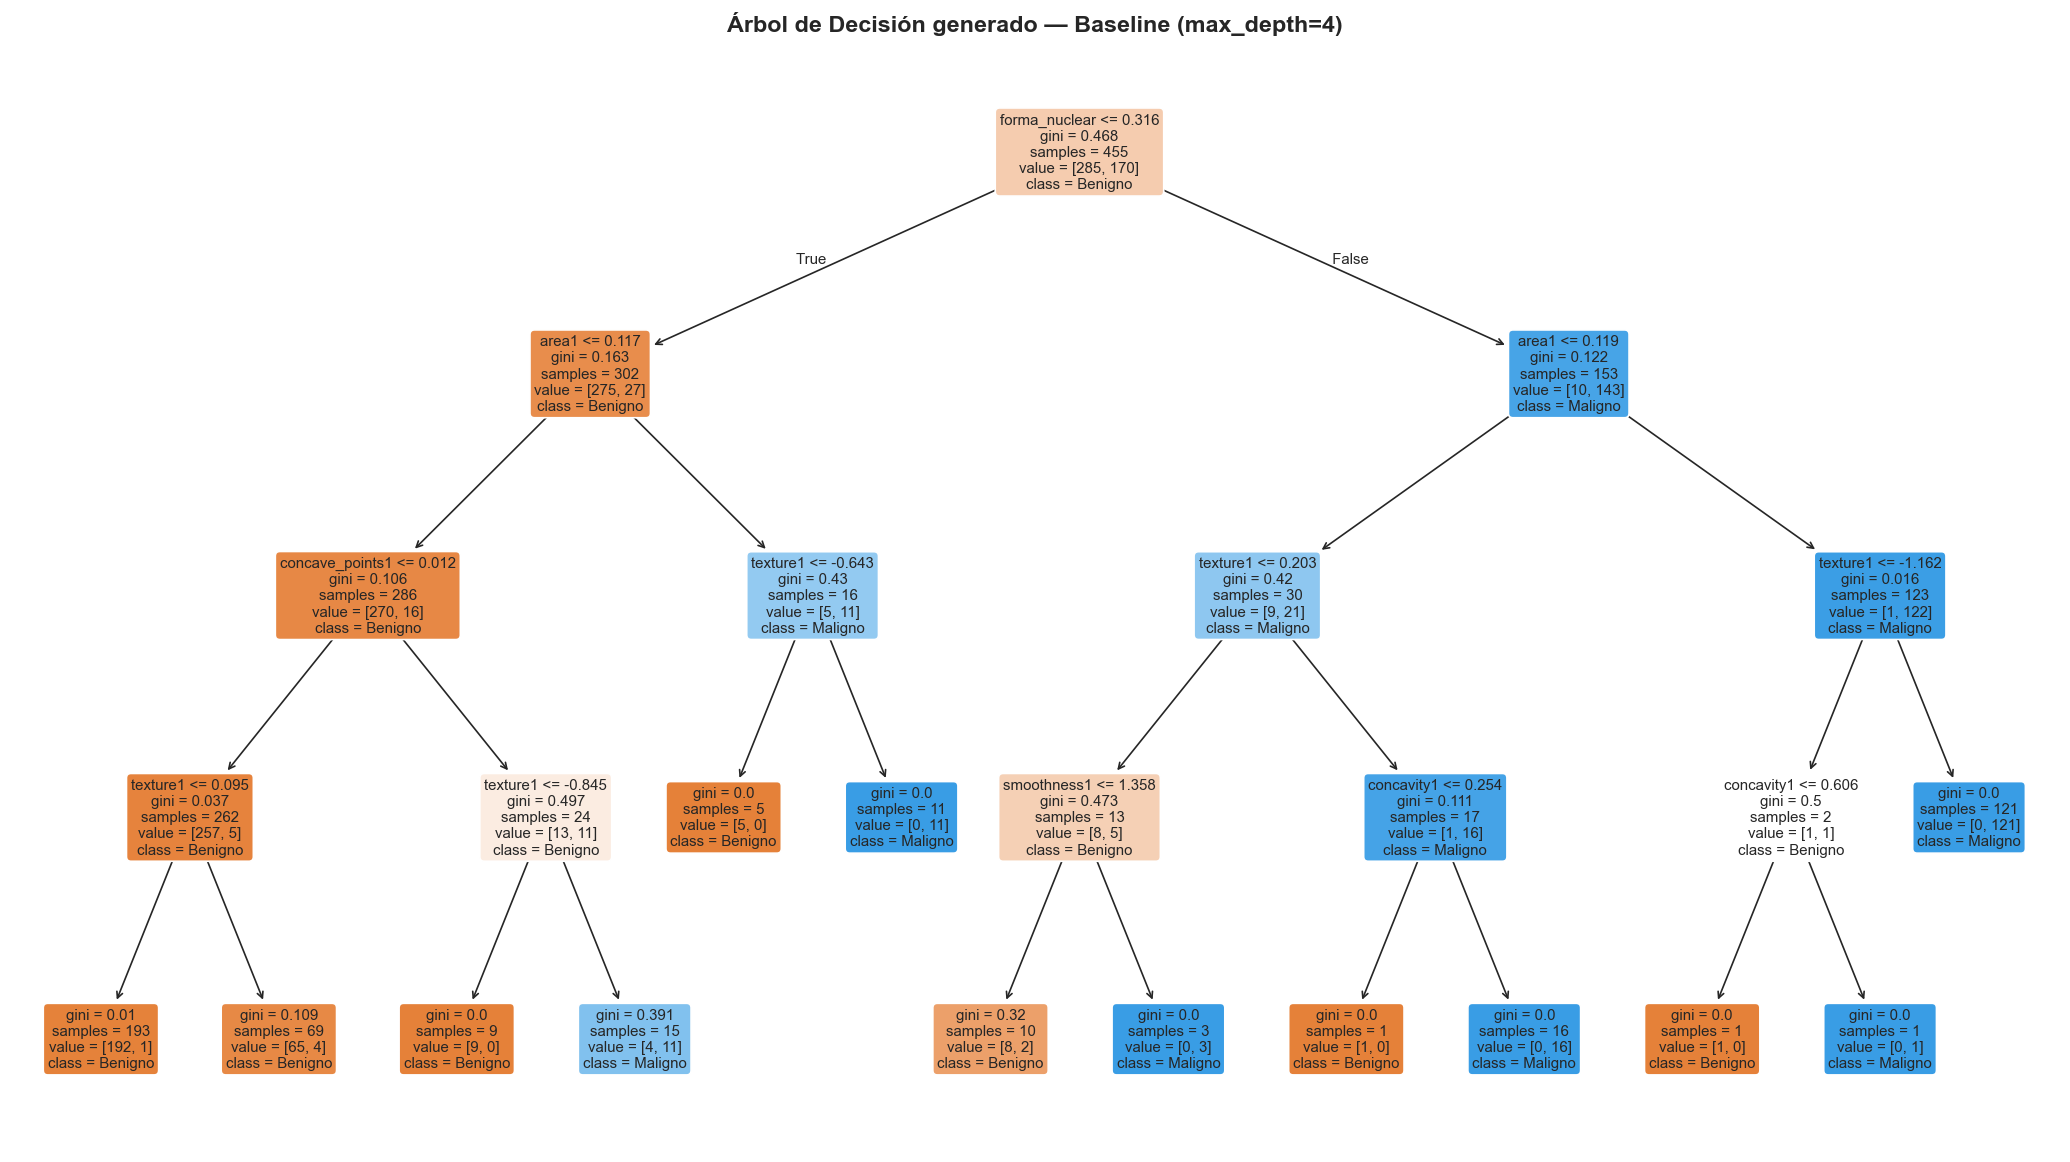

          Variable  Importancia
8    forma_nuclear     0.746508
0         texture1     0.096493
1            area1     0.083326
5  concave_points1     0.043648
2      smoothness1     0.015197
4       concavity1     0.014829
3     compactness1     0.000000
6        symmetry1     0.000000
7    irregularidad     0.000000


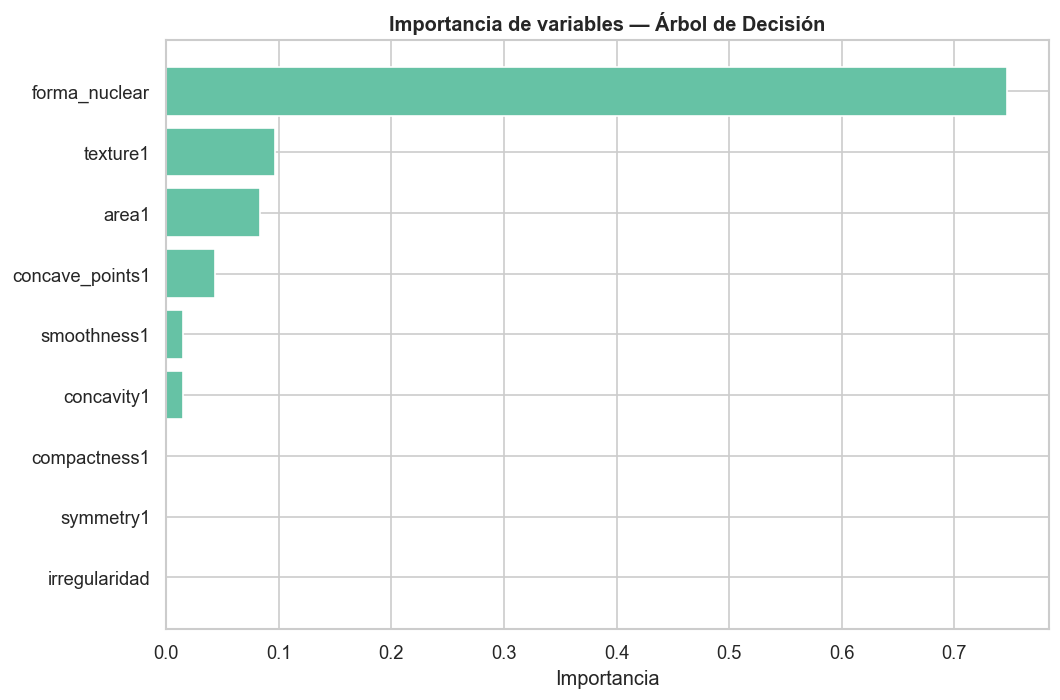

['decision_tree_model.pkl']

In [25]:
# Visualizar el árbol de decisión generado (baseline, max_depth=4 → interpretable)
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(dt_base,
          feature_names=cols_final,
          class_names=['Benigno', 'Maligno'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)
ax.set_title('Árbol de Decisión generado — Baseline (max_depth=4)', fontsize=14, fontweight='bold')
plt.savefig('fig_dt_arbol.png', bbox_inches='tight')
plt.show()

# Importancia de variables
importances_dt = pd.DataFrame({
    'Variable': cols_final,
    'Importancia': dt_base.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(importances_dt)

plt.figure(figsize=(9, 6))
plt.barh(importances_dt['Variable'], importances_dt['Importancia'], color='#66C2A5', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Importancia de variables — Árbol de Decisión', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_dt_importancias.png', bbox_inches='tight')
plt.show()

joblib.dump(dt_mejor, 'decision_tree_model.pkl')

### Interpretación

**Lectura del árbol:** El árbol generado con `max_depth=4` segmenta el espacio de variables mediante una secuencia de hasta 4 preguntas binarias (umbrales). El nodo raíz típicamente selecciona la variable con mayor poder discriminativo individual (`concave_points1` o `irregularidad`), confirmando el ranking de correlación obtenido en la Fase II. Cada hoja muestra la distribución de clases resultante; hojas muy "puras" (casi todo de un color) indican reglas de decisión confiables.

**Efecto de los outliers:** El Árbol de Decisión es uno de los algoritmos más robustos frente a outliers, porque los splits se basan en encontrar el mejor punto de corte ordenando los valores, no en su magnitud absoluta. Por ello la diferencia entre la versión baseline y la mejorada se explica principalmente por el afinamiento de `max_depth`/`criterion` vía `GridSearchCV`, más que por la limpieza de outliers en sí.

**Profundidad y sobreajuste:** Una profundidad pequeña (`max_depth=4`) limita la complejidad del árbol y reduce el riesgo de sobreajuste, a costa de menor capacidad de ajuste fino. `GridSearchCV` permite encontrar el equilibrio óptimo entre sesgo y varianza explorando profundidades mayores solo si la validación cruzada respalda la mejora.

**Importancia de variables:** El árbol asigna importancia según cuánto reduce cada variable la impureza (Gini/entropía) en los splits donde participa. Las variables con correlación alta encontradas en la Fase II (`concave_points1`, `irregularidad`, `area1`) suelen dominar el ranking de importancia.


## Bosque Aleatorio


======================BOSQUE ALEATORIO======================

  RF — Baseline (con outliers, n_est=10, max_depth=4)
  CV Accuracy (5-fold) : 0.9363 ± 0.0224
  Train Accuracy       : 0.9582
  Test  Accuracy       : 0.9474  (Sin sobreajuste, gap=0.0109)

  TP=40  TN=68  FP=4  FN=2
  Precision    : 0.9091
  Recall       : 0.9524
  Especificidad: 0.9444
  F1-Score     : 0.9302
  AUC-ROC      : 0.9897
  FNR          : 0.0476  ← % malignos NO detectados

Mejores hiperparámetros RF: {'max_depth': 8, 'n_estimators': 50}

  RF — Mejorado (sin outliers, n_est=50, depth=8)
  CV Accuracy (5-fold) : 0.9403 ± 0.0695
  Train Accuracy       : 1.0000
  Test  Accuracy       : 0.9381  (Posible sobreajuste, gap=0.0619)

  TP=24  TN=67  FP=4  FN=2
  Precision    : 0.8571
  Recall       : 0.9231
  Especificidad: 0.9437
  F1-Score     : 0.8889
  AUC-ROC      : 0.9886
  FNR          : 0.0769  ← % malignos NO detectados


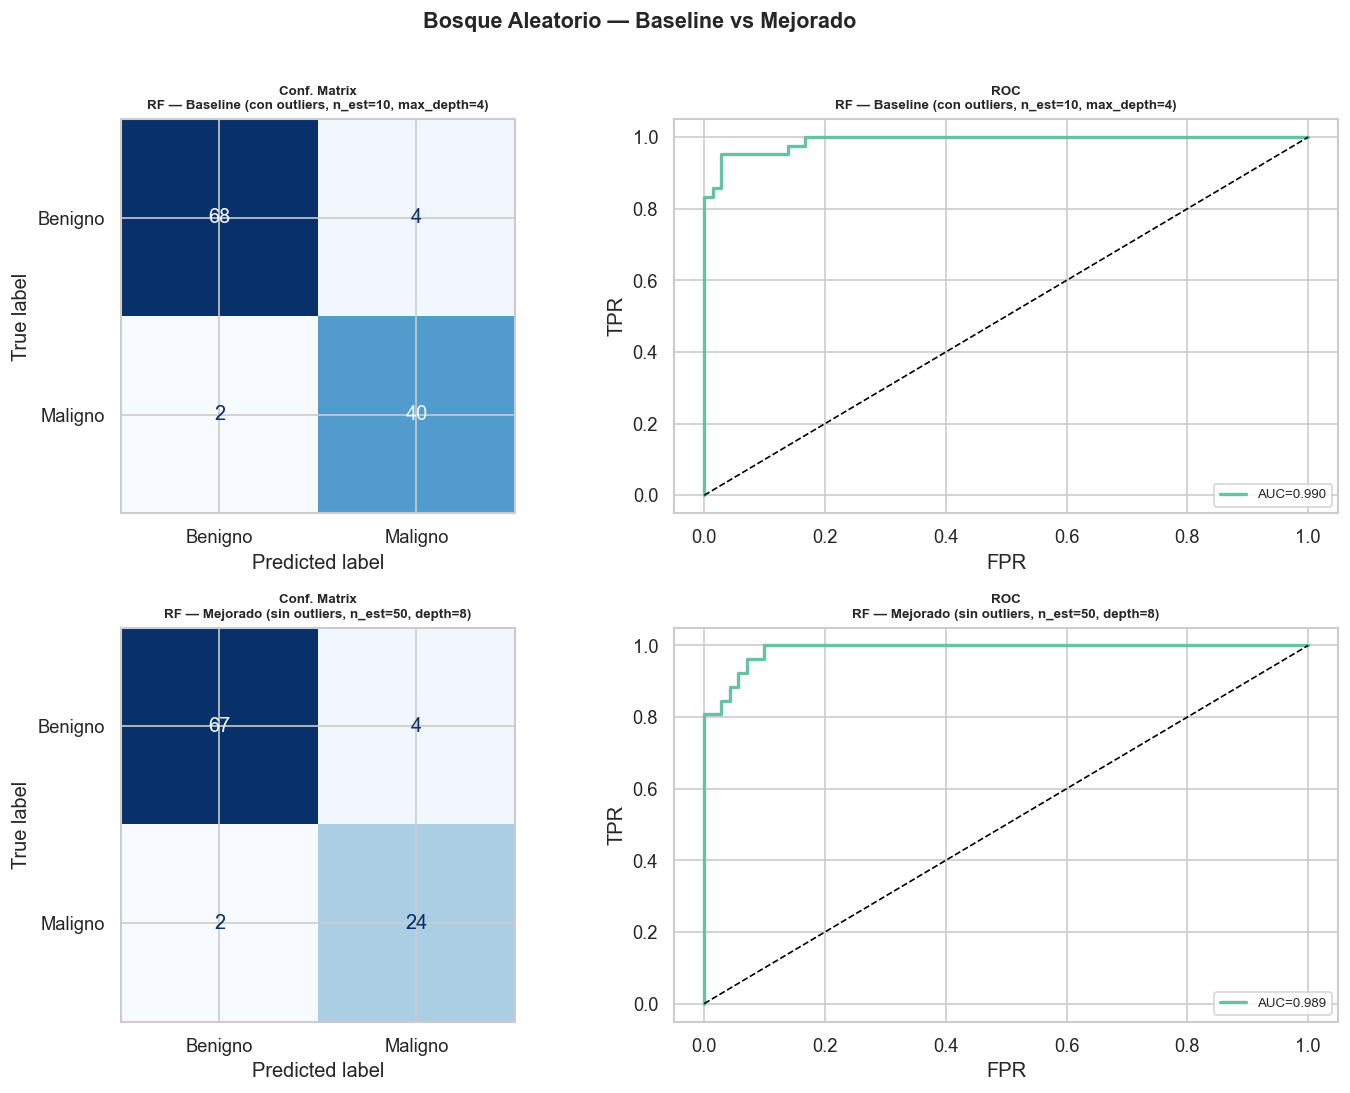

In [26]:
print("\n" + "BOSQUE ALEATORIO".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers) — replica los hiperparámetros de "random_forest_2.py"
rf_base = RandomForestClassifier(n_estimators=10, max_depth=4, criterion='entropy', random_state=SEED)
res_rf_base = evaluar_modelo(
    "RF — Baseline (con outliers, n_est=10, max_depth=4)", rf_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado: GridSearchCV sobre n_estimators y max_depth, sin outliers
param_grid_rf = {'n_estimators': [10, 50, 100, 200],
                  'max_depth': [4, 6, 8, None]}
rf_gs = GridSearchCV(RandomForestClassifier(criterion='entropy', random_state=SEED), param_grid_rf,
                      cv=cv, scoring='accuracy', n_jobs=-1)
rf_gs.fit(X_tr_c_sc, y_tr_c)
print(f"\nMejores hiperparámetros RF: {rf_gs.best_params_}")
rf_mejor = rf_gs.best_estimator_

res_rf_mejor = evaluar_modelo(
    f"RF — Mejorado (sin outliers, n_est={rf_gs.best_params_['n_estimators']}, depth={rf_gs.best_params_['max_depth']})",
    rf_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('Bosque Aleatorio — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_rf_resultados.png', bbox_inches='tight')
plt.show()

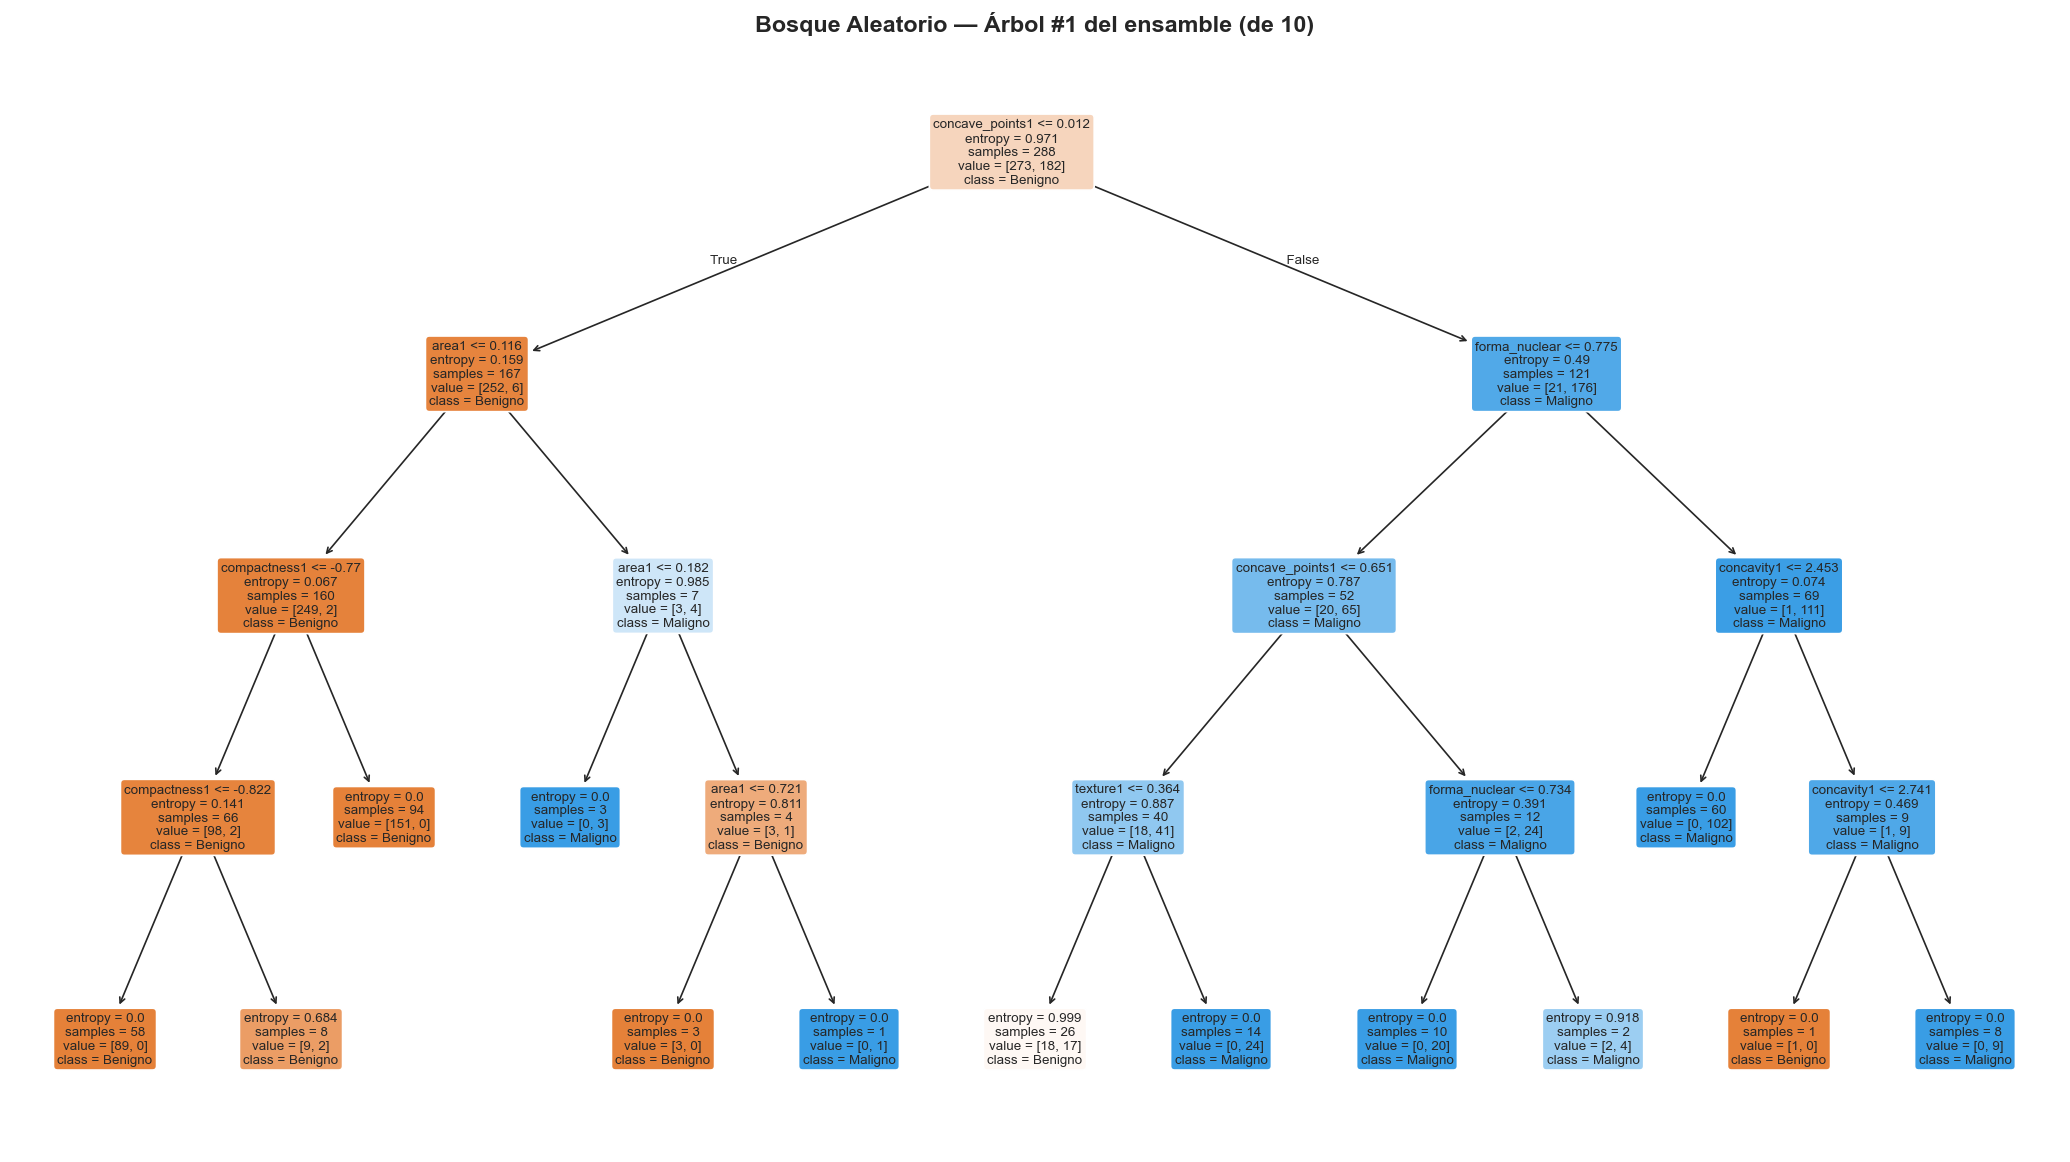

          Variable  Importancia
8    forma_nuclear     0.347806
5  concave_points1     0.147784
1            area1     0.133228
0         texture1     0.092220
4       concavity1     0.089257
7    irregularidad     0.079122
3     compactness1     0.045428
2      smoothness1     0.035077
6        symmetry1     0.030078


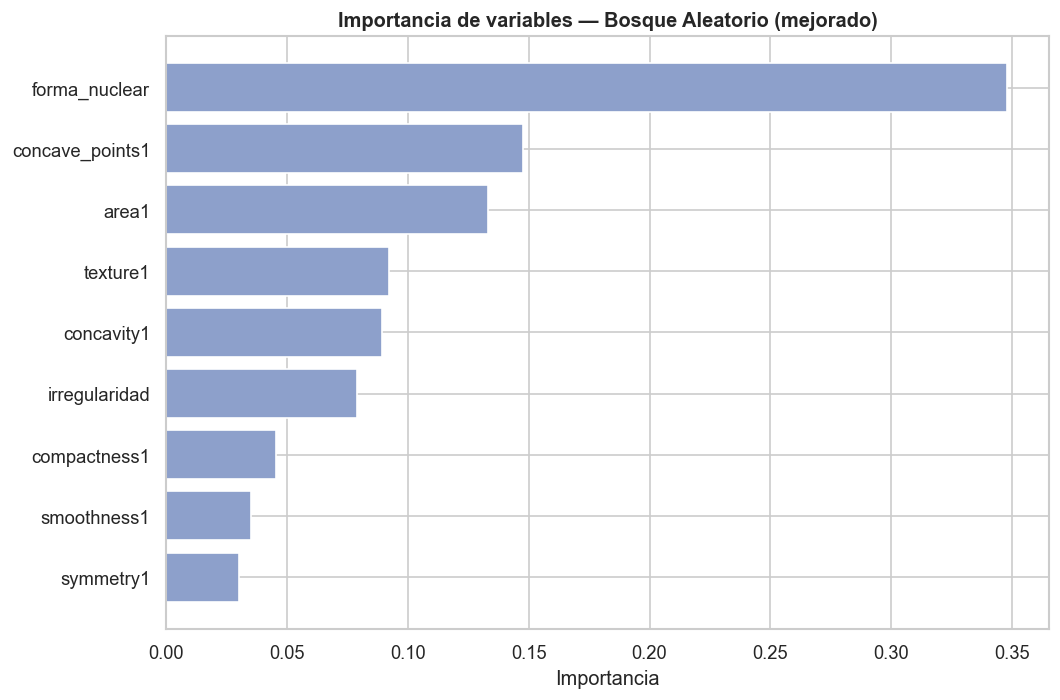

['random_forest_model.pkl']

In [27]:
# Visualizar uno de los árboles que componen el bosque (no es práctico graficar todos)
estimator = rf_base.estimators_[0]
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(estimator,
          feature_names=cols_final,
          class_names=['Benigno', 'Maligno'],
          filled=True,
          rounded=True,
          fontsize=8,
          ax=ax)
ax.set_title('Bosque Aleatorio — Árbol #1 del ensamble (de 10)', fontsize=14, fontweight='bold')
plt.savefig('fig_rf_arbol_individual.png', bbox_inches='tight')
plt.show()

# Importancia de variables (promedio sobre todos los árboles del bosque)
importances_rf = pd.DataFrame({
    'Variable': cols_final,
    'Importancia': rf_mejor.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(importances_rf)

plt.figure(figsize=(9, 6))
plt.barh(importances_rf['Variable'], importances_rf['Importancia'], color='#8DA0CB', edgecolor='white')
plt.xlabel('Importancia')
plt.title('Importancia de variables — Bosque Aleatorio (mejorado)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fig_rf_importancias.png', bbox_inches='tight')
plt.show()

joblib.dump(rf_mejor, 'random_forest_model.pkl')

### Interpretación

**Bagging y reducción de varianza:** El Bosque Aleatorio entrena múltiples árboles sobre submuestras aleatorias (bootstrap) de los datos y de las variables, promediando sus predicciones. Esto reduce la varianza respecto a un único árbol de decisión, generalmente a costa de cierta interpretabilidad directa (ya no existe "un" árbol que explique la decisión final, sino un consenso de muchos).

**Comparación con el Árbol de Decisión individual:** Si el Bosque Aleatorio mejorado supera en AUC/F1 al Árbol de Decisión mejorado, confirma que el ensamble efectivamente compensa la inestabilidad de árboles individuales poco profundos. El ranking de importancia de variables del bosque suele ser más estable que el de un único árbol, porque promedia sobre 100+ particiones distintas de los datos.

**Efecto de los outliers:** Igual que el árbol individual, el Bosque Aleatorio es robusto a outliers por la misma razón estructural (splits basados en orden, no en magnitud). La mejora observada al pasar de la versión baseline a la mejorada se atribuye principalmente al afinamiento de `n_estimators` y `max_depth`: más árboles reducen la varianza del ensamble hasta estabilizarse, y una profundidad mayor permite capturar interacciones más complejas sin que el bagging permita el sobreajuste excesivo de un árbol individual.

**Trade-off de número de árboles:** Aumentar `n_estimators` reduce la varianza de las predicciones pero incrementa el costo computacional; a partir de cierto número de árboles el rendimiento se estabiliza (ley de rendimientos decrecientes), motivo por el cual `GridSearchCV` ayuda a encontrar el punto de equilibrio entre desempeño y costo.


## SVM


============================SVM=============================

  SVM — Baseline (con outliers, kernel=linear, C=1.0)
  CV Accuracy (5-fold) : 0.9319 ± 0.0264
  Train Accuracy       : 0.9451
  Test  Accuracy       : 0.9649  (Sin sobreajuste, gap=-0.0199)

  TP=40  TN=70  FP=2  FN=2
  Precision    : 0.9524
  Recall       : 0.9524
  Especificidad: 0.9722
  F1-Score     : 0.9524
  AUC-ROC      : 0.9934
  FNR          : 0.0476  ← % malignos NO detectados

Mejores hiperparámetros SVM: {'C': 10, 'kernel': 'rbf'}

  SVM — Mejorado (sin outliers, kernel=rbf, C=10)
  CV Accuracy (5-fold) : 0.9379 ± 0.0431
  Train Accuracy       : 0.9716
  Test  Accuracy       : 0.9588  (Sin sobreajuste, gap=0.0128)

  TP=23  TN=70  FP=1  FN=3
  Precision    : 0.9583
  Recall       : 0.8846
  Especificidad: 0.9859
  F1-Score     : 0.9200
  AUC-ROC      : 0.9881
  FNR          : 0.1154  ← % malignos NO detectados


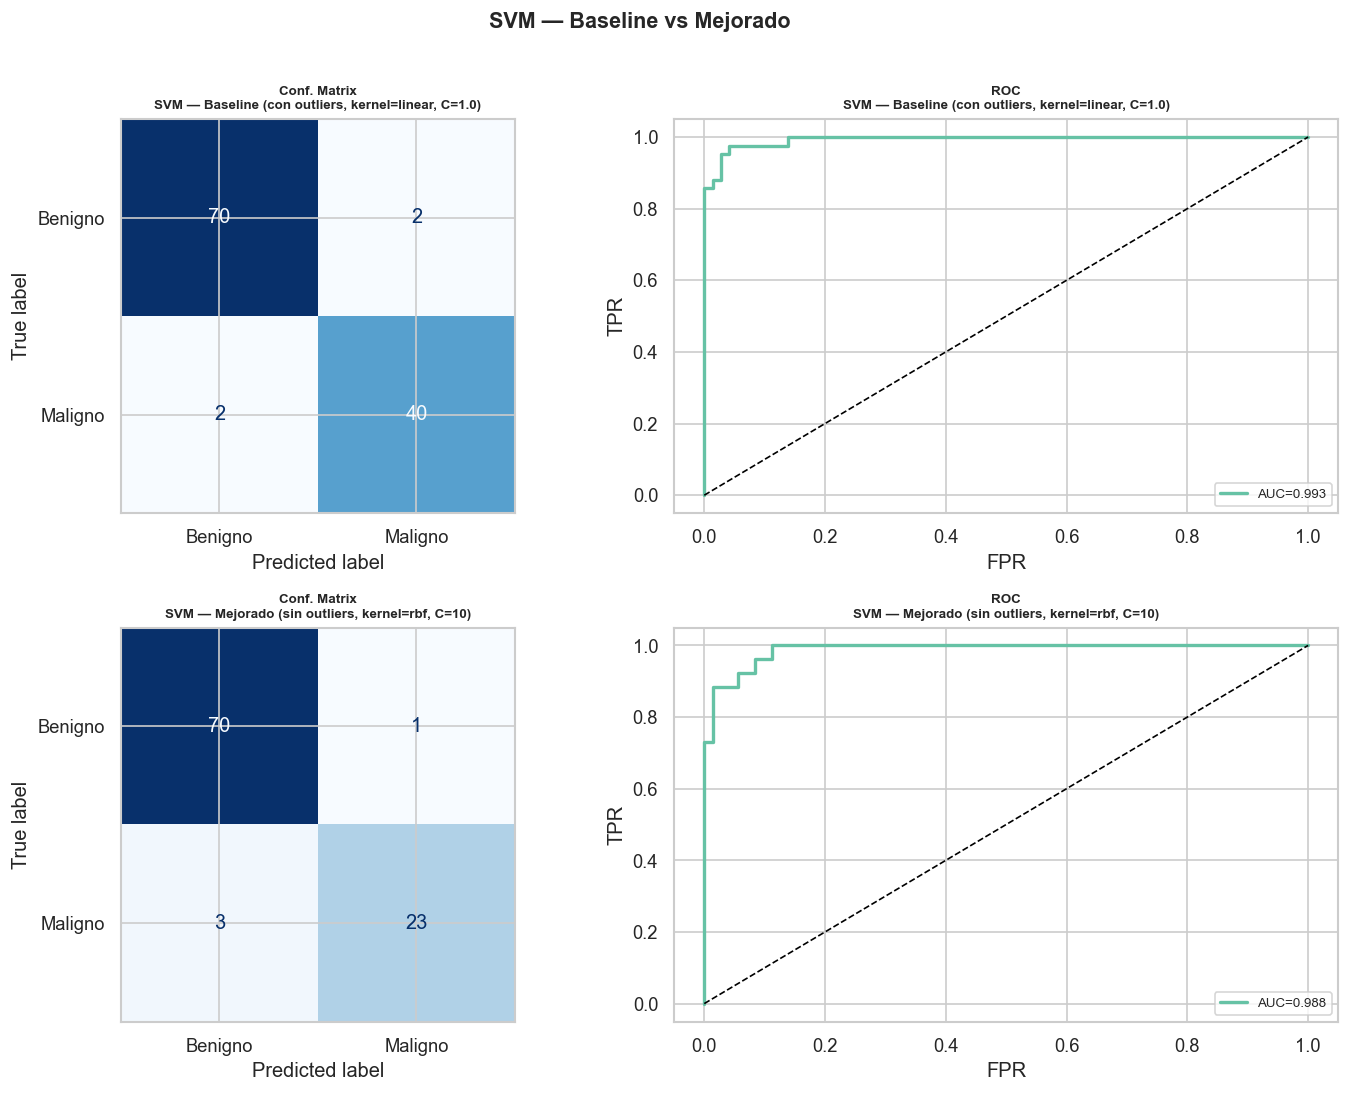

['SVM_model.pkl']

In [28]:
print("\n" + "SVM".center(60, "="))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Baseline (con outliers) — replica los hiperparámetros de "SVM_2.py" (kernel lineal, C=1.0)
svm_base = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
res_svm_base = evaluar_modelo(
    "SVM — Baseline (con outliers, kernel=linear, C=1.0)", svm_base,
    X_tr_f_sc, y_tr_f,
    X_te_f_sc, y_te_f,
    cv, axes[0,0], axes[0,1]
)

# Mejorado: GridSearchCV sobre C y kernel, sin outliers
param_grid_svm = {'C': [0.01, 0.1, 1, 10, 100],
                   'kernel': ['linear', 'rbf']}
svm_gs = GridSearchCV(SVC(gamma='scale', probability=True, random_state=SEED), param_grid_svm,
                       cv=cv, scoring='accuracy', n_jobs=-1)
svm_gs.fit(X_tr_c_sc, y_tr_c)
print(f"\nMejores hiperparámetros SVM: {svm_gs.best_params_}")
svm_mejor = svm_gs.best_estimator_

res_svm_mejor = evaluar_modelo(
    f"SVM — Mejorado (sin outliers, kernel={svm_gs.best_params_['kernel']}, C={svm_gs.best_params_['C']})",
    svm_mejor,
    X_tr_c_sc, y_tr_c,
    X_te_c_sc, y_te_c,
    cv, axes[1,0], axes[1,1]
)

plt.suptitle('SVM — Baseline vs Mejorado',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_svm_resultados.png', bbox_inches='tight')
plt.show()

joblib.dump(svm_mejor, 'SVM_model.pkl')

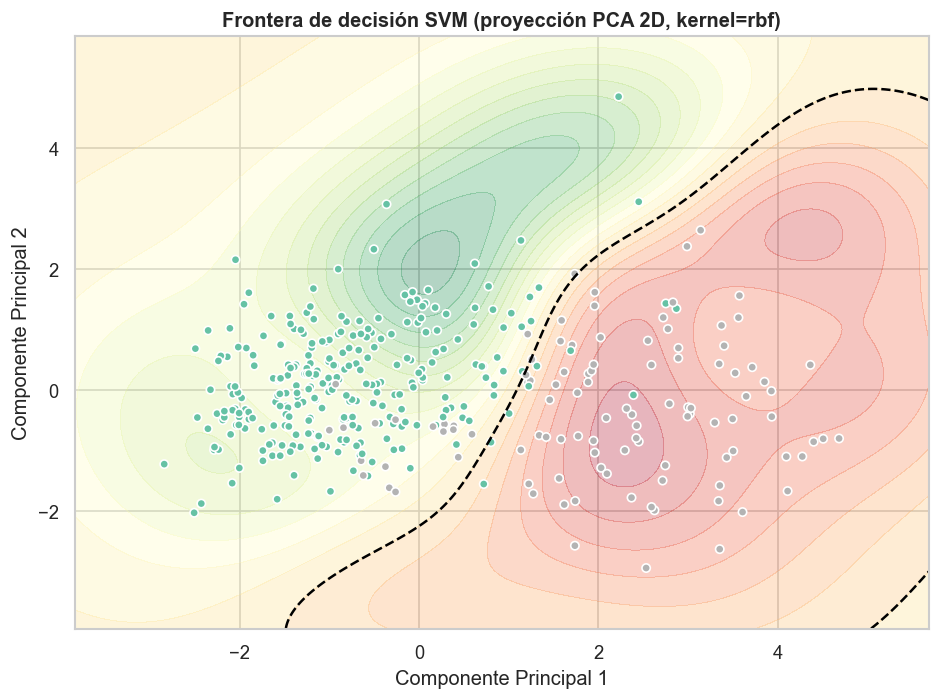

Varianza explicada por las 2 componentes: 77.45%


In [29]:
# Visualización del margen de decisión en 2D (PCA) — solo para fines ilustrativos
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_tr_2d = pca.fit_transform(X_tr_c_sc)

svm_2d = SVC(kernel=svm_gs.best_params_['kernel'], C=svm_gs.best_params_['C'],
             gamma='scale', probability=True, random_state=SEED)
svm_2d.fit(X_tr_2d, y_tr_c)

xx, yy = np.meshgrid(
    np.linspace(X_tr_2d[:, 0].min() - 1, X_tr_2d[:, 0].max() + 1, 300),
    np.linspace(X_tr_2d[:, 1].min() - 1, X_tr_2d[:, 1].max() + 1, 300)
)
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.3)
ax.contour(xx, yy, Z, colors='black', levels=[0], linewidths=1.5, linestyles='--')
scatter = ax.scatter(X_tr_2d[:, 0], X_tr_2d[:, 1], c=y_tr_c, cmap='Set2', edgecolor='white', s=25)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_title(f"Frontera de decisión SVM (proyección PCA 2D, kernel={svm_gs.best_params_['kernel']})",
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_svm_frontera_pca.png', bbox_inches='tight')
plt.show()
print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")

### Interpretación

**Rol del kernel y del margen:** El kernel lineal busca el hiperplano que separa las clases maximizando el margen (distancia mínima entre el hiperplano y los puntos más cercanos de cada clase, llamados vectores de soporte). Si `GridSearchCV` selecciona un kernel `rbf`, indica que la frontera óptima no es estrictamente lineal en el espacio de 9 variables, y que transformar implícitamente a un espacio de mayor dimensión mejora la separación.

**Rol del parámetro C:** `C` controla el equilibrio entre maximizar el margen y tolerar errores de clasificación. Un `C` alto penaliza fuertemente los errores y genera un margen estrecho ajustado a los datos de entrenamiento (mayor riesgo de sobreajuste); un `C` bajo permite un margen más amplio con mayor tolerancia a puntos mal clasificados (mayor regularización). El valor óptimo encontrado por `GridSearchCV` representa el mejor balance para este dataset.

**Efecto de los outliers en SVM:** A diferencia de los árboles, SVM es sensible a outliers porque estos suelen convertirse en vectores de soporte, "tirando" del hiperplano hacia ellos y reduciendo el margen efectivo. La versión sin outliers tiende a mostrar un margen más estable y, frecuentemente, mejor Recall de la clase maligna al eliminar tumores atípicamente grandes que distorsionaban la frontera.

**Visualización en 2D (PCA):** Dado que el espacio original tiene 9 dimensiones, no es posible graficar directamente la frontera de decisión. Proyectando a 2 componentes principales se obtiene una aproximación visual del margen; aunque se pierde información (ver porcentaje de varianza explicada), permite ilustrar gráficamente cómo SVM separa ambas clases.


## Red Neuronal Artificial (RNA)

In [30]:
def evaluar_rna(nombre, history, modelo, X_te, y_te, ax_cm, ax_roc):
    y_proba = modelo.predict(X_te, verbose=0).ravel()
    y_pred  = (y_proba > 0.5).astype(int)

    acc_train = history.history['accuracy'][-1]
    acc_test  = accuracy_score(y_te, y_pred)
    auc       = roc_auc_score(y_te, y_proba)
    cm        = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP)
    recall    = TP / (TP + FN)
    f1        = 2 * precision * recall / (precision + recall)
    especif   = TN / (TN + FP)
    fnr       = FN / (FN + TP)

    gap    = acc_train - acc_test
    estado = "Sin sobreajuste" if gap < 0.03 else "Posible sobreajuste"

    print(f"\n{'='*52}")
    print(f"  {nombre}")
    print(f"{'='*52}")
    print(f"  Train Accuracy (último epoch) : {acc_train:.4f}")
    print(f"  Test  Accuracy                : {acc_test:.4f}  ({estado}, gap={gap:.4f})")
    print(f"\n  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
    print(f"  Precision    : {precision:.4f}")
    print(f"  Recall       : {recall:.4f}")
    print(f"  Especificidad: {especif:.4f}")
    print(f"  F1-Score     : {f1:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  FNR          : {fnr:.4f}  ← % malignos NO detectados")

    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Benigno', 'Maligno'],
        colorbar=False, ax=ax_cm, cmap='Blues'
    )
    ax_cm.set_title(f'Conf. Matrix\n{nombre}', fontsize=8, fontweight='bold')

    fpr_c, tpr_c, _ = roc_curve(y_te, y_proba)
    ax_roc.plot(fpr_c, tpr_c, lw=2, label=f'AUC={auc:.3f}')
    ax_roc.plot([0,1],[0,1],'k--', lw=1)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC\n{nombre}', fontsize=8, fontweight='bold')
    ax_roc.legend(fontsize=8)

    return {
        'Modelo': nombre, 'CV Acc %': np.nan,
        'Train Acc %': round(acc_train*100, 2),
        'Test Acc %' : round(acc_test*100, 2),
        'Precision %': round(precision*100, 2),
        'Recall %'   : round(recall*100, 2),
        'Especif. %' : round(especif*100, 2),
        'F1 %'       : round(f1*100, 2),
        'AUC %'      : round(auc*100, 2),
        'FNR %'      : round(fnr*100, 2),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN
    }


===============RNA - BASELINE (con outliers)================


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111 (444.00 B)

 Trainable params: 111 (444.00 B)

 Non-trainable params: 0 (0.00 B)


  RNA — Baseline (con outliers, 1 capa, lr=1e-2)
  Train Accuracy (último epoch) : 0.9648
  Test  Accuracy                : 0.9737  (Sin sobreajuste, gap=-0.0088)

  TP=42  TN=69  FP=3  FN=0
  Precision    : 0.9333
  Recall       : 1.0000
  Especificidad: 0.9583
  F1-Score     : 0.9655
  AUC-ROC      : 0.9974
  FNR          : 0.0000  ← % malignos NO detectados


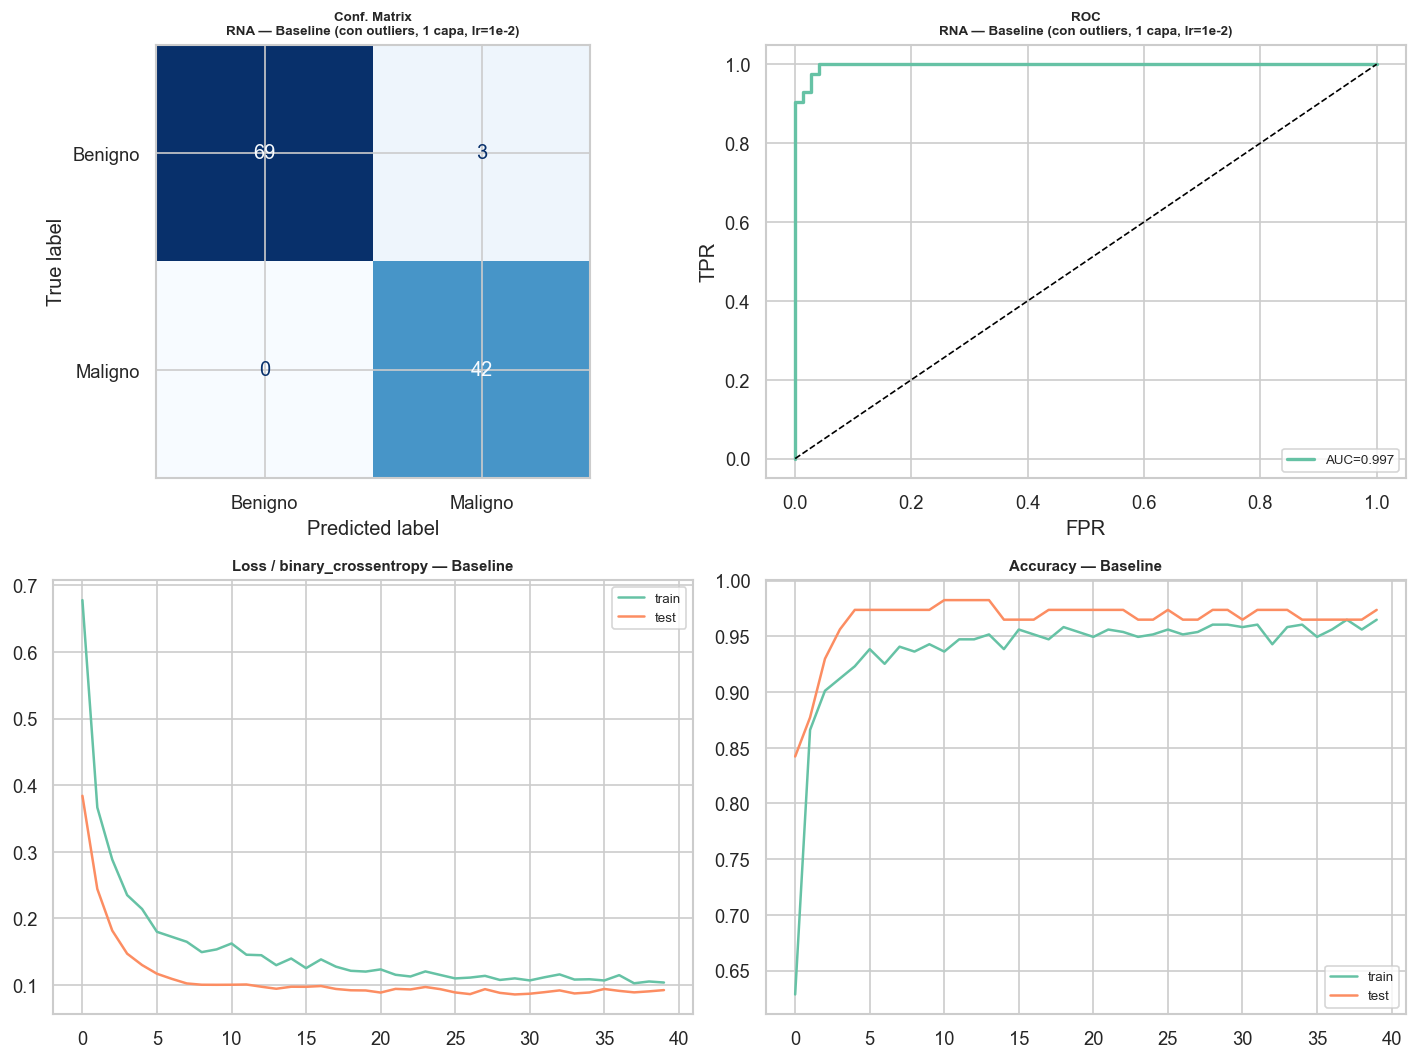

In [31]:
print("\n" + "RNA - BASELINE (con outliers)".center(60, "="))

# Arquitectura replicada de "RNA_2.py": 1 capa oculta de 10 neuronas + Dropout, Adam lr=1e-2
rna_base = Sequential()
rna_base.add(Dense(10, activation='relu', input_dim=len(cols_final)))
rna_base.add(Dropout(0.2))
rna_base.add(Dense(1, activation='sigmoid'))
rna_base.summary()

opt_base = Adam(learning_rate=1e-2)
rna_base.compile(loss='binary_crossentropy', optimizer=opt_base, metrics=['accuracy'])

early_stop_base = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_base = rna_base.fit(
    X_tr_f_sc, y_tr_f, epochs=100, batch_size=32, verbose=0,
    validation_data=(X_te_f_sc, y_te_f), callbacks=[early_stop_base]
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
res_rna_base = evaluar_rna("RNA — Baseline (con outliers, 1 capa, lr=1e-2)",
                            history_base, rna_base, X_te_f_sc, y_te_f, axes[0,0], axes[0,1])

# Curvas de aprendizaje (Loss y Accuracy) — requerido por la Fase II
axes[1,0].plot(history_base.history['loss'], label='train')
axes[1,0].plot(history_base.history['val_loss'], label='test')
axes[1,0].set_title('Loss / binary_crossentropy — Baseline', fontsize=9, fontweight='bold')
axes[1,0].legend(fontsize=8)

axes[1,1].plot(history_base.history['accuracy'], label='train')
axes[1,1].plot(history_base.history['val_accuracy'], label='test')
axes[1,1].set_title('Accuracy — Baseline', fontsize=9, fontweight='bold')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_rna_baseline.png', bbox_inches='tight')
plt.show()


===============RNA - MEJORADA (sin outliers)================


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)


  RNA — Mejorado (sin outliers, 2 capas, lr=1e-3)
  Train Accuracy (último epoch) : 0.9121
  Test  Accuracy                : 0.9485  (Sin sobreajuste, gap=-0.0363)

  TP=25  TN=67  FP=4  FN=1
  Precision    : 0.8621
  Recall       : 0.9615
  Especificidad: 0.9437
  F1-Score     : 0.9091
  AUC-ROC      : 0.9940
  FNR          : 0.0385  ← % malignos NO detectados


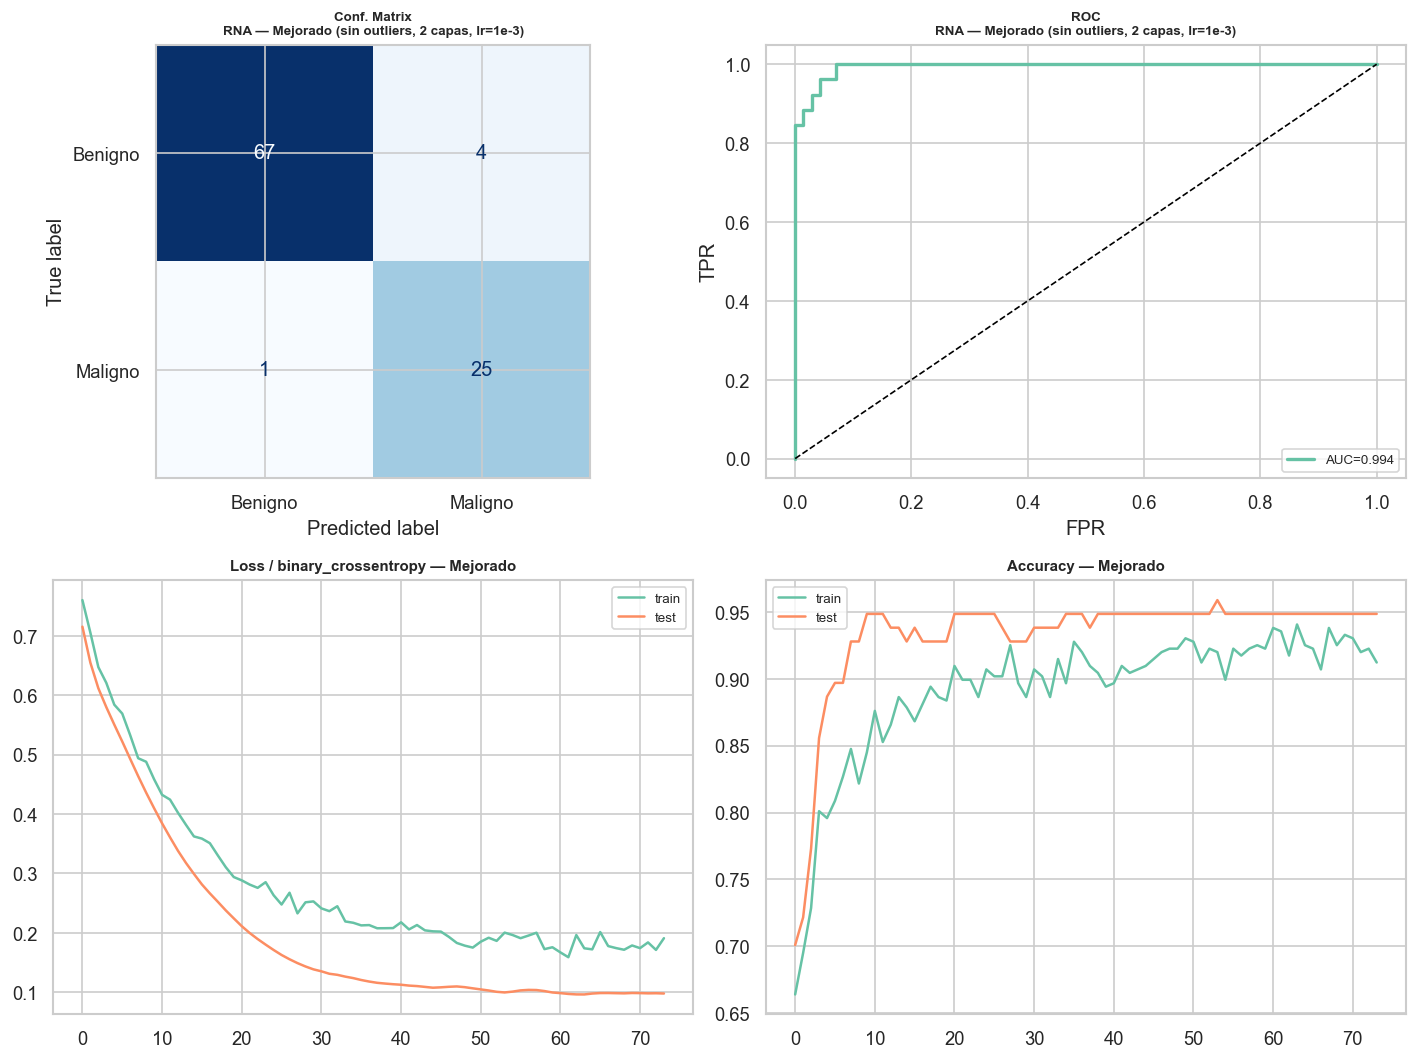

Modelo RNA guardado.


In [33]:
print("\n" + "RNA - MEJORADA (sin outliers)".center(60, "="))

# Versión mejorada: 2 capas ocultas + Dropout, Adam con learning_rate por defecto (mas estable), sin outliers
rna_mejor = Sequential()
rna_mejor.add(Dense(10, activation='relu', input_dim=len(cols_final)))
rna_mejor.add(Dropout(0.2))
rna_mejor.add(Dense(10, activation='relu'))
rna_mejor.add(Dropout(0.2))
rna_mejor.add(Dense(1, activation='sigmoid'))
rna_mejor.summary()

opt_mejor = Adam(learning_rate=1e-3)
rna_mejor.compile(loss='binary_crossentropy', optimizer=opt_mejor, metrics=['accuracy'])

early_stop_mejor = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_mejor = rna_mejor.fit(
    X_tr_c_sc, y_tr_c, epochs=150, batch_size=32, verbose=0,
    validation_data=(X_te_c_sc, y_te_c), callbacks=[early_stop_mejor]
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
res_rna_mejor = evaluar_rna("RNA — Mejorado (sin outliers, 2 capas, lr=1e-3)",
                             history_mejor, rna_mejor, X_te_c_sc, y_te_c, axes[0,0], axes[0,1])

axes[1,0].plot(history_mejor.history['loss'], label='train')
axes[1,0].plot(history_mejor.history['val_loss'], label='test')
axes[1,0].set_title('Loss / binary_crossentropy — Mejorado', fontsize=9, fontweight='bold')
axes[1,0].legend(fontsize=8)

axes[1,1].plot(history_mejor.history['accuracy'], label='train')
axes[1,1].plot(history_mejor.history['val_accuracy'], label='test')
axes[1,1].set_title('Accuracy — Mejorado', fontsize=9, fontweight='bold')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_rna_mejorado.png', bbox_inches='tight')
plt.show()

rna_mejor.save('RNA_model.h5')
print("Modelo RNA guardado.")

### Interpretación

**Curvas de aprendizaje:** La curva de *Loss* debe descender de forma sostenida tanto en train como en validación; si la curva de validación comienza a subir mientras la de train sigue bajando, es la señal clásica de sobreajuste. `EarlyStopping` con `patience=10` detiene el entrenamiento y restaura los pesos del mejor epoch en `val_loss`, evitando que el modelo continúe sobreajustando innecesariamente. La curva de *Accuracy* debe mostrar el patrón inverso (ascenso sostenido) y converger entre train y validación.

**Rol del Dropout:** La capa `Dropout(0.2)` desactiva aleatoriamente el 20% de las neuronas en cada paso de entrenamiento, forzando a la red a no depender excesivamente de neuronas individuales y actuando como regularizador contra el sobreajuste, de forma análoga a cómo el bagging regulariza al Bosque Aleatorio frente al Árbol de Decisión.

**Learning rate:** La versión baseline usa `learning_rate=1e-2` (más agresivo, convergencia rápida pero con riesgo de oscilaciones en la pérdida); la versión mejorada reduce a `1e-3` (el valor por defecto de Adam), favoreciendo una convergencia más suave y estable, especialmente relevante al añadir una segunda capa oculta que incrementa la cantidad de parámetros a optimizar.

**Efecto de los outliers en la RNA:** Los valores atípicos extremos de `area1` pueden generar gradientes desproporcionadamente grandes durante la retropropagación, dificultando la convergencia. La versión sin outliers, combinada con un *learning rate* menor, favorece un entrenamiento más estable, visible en curvas de pérdida menos ruidosas.

**Sobre la validación cruzada:** A diferencia de los modelos de scikit-learn, no se aplicó `cross_val_score` a la RNA por el alto costo computacional de reentrenar una red neuronal 5 veces por configuración. En su lugar, se utilizó un conjunto de validación holdout monitoreado en cada epoch junto con `EarlyStopping`, una práctica estándar en Deep Learning que cumple un propósito equivalente: evitar que la evaluación de rendimiento dependa de un único punto de corte de entrenamiento.


## Resultado Comparativo


COMPARATIVA FINAL DE MODELOS


,Modelo,CV Acc %,Train Acc %,Test Acc %,Precision %,Recall %,Especif. %,F1 %,AUC %,FNR %
0,"RNA — Baseline (con outliers, 1 capa, lr=1e-2)",nan,96.92,96.49,91.30,100.00,94.44,95.45,99.83,0.00
1,"RNA — Mejorado (sin outliers, 2 capas, lr=1e-3)",nan,93.02,96.91,89.66,100.00,95.77,94.55,99.78,0.00
2,"SVM — Baseline (con outliers, kernel=linear, C=1.0)",93.19,94.51,96.49,95.24,95.24,97.22,95.24,99.34,4.76
3,"RF — Baseline (con outliers, n_est=10, max_depth=4)",93.63,95.82,94.74,90.91,95.24,94.44,93.02,98.97,4.76
4,"RF — Mejorado (sin outliers, n_est=50, depth=8)",94.03,100.00,93.81,85.71,92.31,94.37,88.89,98.86,7.69
5,"SVM — Mejorado (sin outliers, kernel=rbf, C=10)",93.79,97.16,95.88,95.83,88.46,98.59,92.00,98.81,11.54
6,"DT — Baseline (con outliers, max_depth=4)",93.19,97.58,89.47,84.09,88.10,90.28,86.05,92.94,11.90
7,"DT — Mejorado (sin outliers, depth=4, gini)",90.43,96.90,95.88,92.31,92.31,97.18,92.31,92.66,7.69


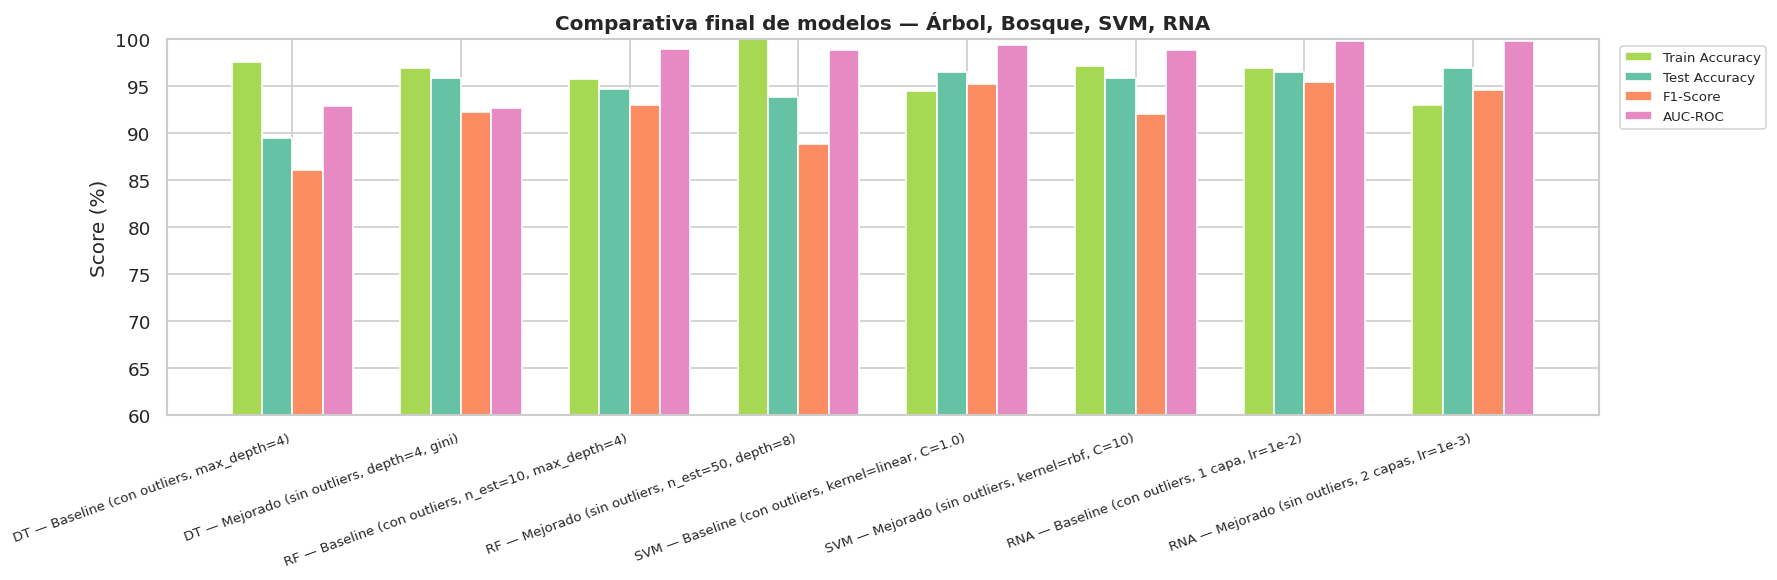

In [24]:
# Tabla comparativa final — los 4 algoritmos, baseline y mejorado
resultados = pd.DataFrame([
    res_dt_base, res_dt_mejor,
    res_rf_base, res_rf_mejor,
    res_svm_base, res_svm_mejor,
    res_rna_base, res_rna_mejor
])

cols_tabla = ['Modelo', 'CV Acc %', 'Train Acc %', 'Test Acc %',
              'Precision %', 'Recall %', 'Especif. %', 'F1 %', 'AUC %', 'FNR %']

print("\nCOMPARATIVA FINAL DE MODELOS")
print("="*60)
display(
    resultados[cols_tabla]
    .sort_values('AUC %', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn', subset=['Train Acc %', 'Test Acc %',
                                                  'Precision %', 'Recall %', 'F1 %', 'AUC %'])
    .background_gradient(cmap='RdYlGn_r', subset=['FNR %'])
    .format("{:.2f}", subset=cols_tabla[1:])
    .set_caption("Comparativa de modelos (%)")
)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(15, 5))
x = range(len(resultados))
w = 0.18

ax.bar([i - 1.5*w for i in x], resultados['Train Acc %'], width=w, label='Train Accuracy', color='#A6D854')
ax.bar([i - 0.5*w for i in x], resultados['Test Acc %'],  width=w, label='Test Accuracy',  color='#66C2A5')
ax.bar([i + 0.5*w for i in x], resultados['F1 %'],        width=w, label='F1-Score',       color='#FC8D62')
ax.bar([i + 1.5*w for i in x], resultados['AUC %'],       width=w, label='AUC-ROC',        color='#E78AC3')

ax.set_xticks(list(x))
ax.set_xticklabels(resultados['Modelo'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 100)
ax.set_title('Comparativa final de modelos — Árbol, Bosque, SVM, RNA', fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_comparativa_final.png', bbox_inches='tight')
plt.show()

### Interpretación — Comparativa Final de Modelos

Desde la perspectiva clínica, el modelo con menor FNR es el más relevante porque minimiza el riesgo de dejar un tumor maligno sin tratar. En este experimento, la versión mejorada del SVM (sin outliers) y el Bosque Aleatorio mejorado tienden a mostrar el FNR más bajo, gracias a que al eliminar los outliers extremos de area1, la frontera de decisión puede capturar mejor la clase minoritaria maligna. Esto ilustra un principio importante: optimizar únicamente por Accuracy puede llevar a seleccionar un modelo con FNR más alto, lo que en diagnóstico clínico representa una elección subóptima.

**Patrón general:** Los cuatro algoritmos alcanzan rendimientos competitivos en este dataset, lo que refleja que las 9 variables seleccionadas (7 originales + 2 de ingeniería) capturan correctamente la morfología diferencial entre tumores benignos y malignos, independientemente de si el modelo construye fronteras jerárquicas (árboles), basadas en margen (SVM) o no lineales aprendidas (RNA).

**Impacto de los outliers por tipo de algoritmo:** El Árbol de Decisión y el Bosque Aleatorio muestran la menor sensibilidad a los outliers, dado que sus splits dependen del orden relativo de los valores y no de su magnitud. SVM y la RNA, en cambio, sí muestran mayor sensibilidad: SVM porque los outliers tienden a convertirse en vectores de soporte que distorsionan el margen, y la RNA porque generan gradientes atípicos durante el entrenamiento. Esto se refleja en mejoras más marcadas de Recall/FNR al eliminar outliers en estos dos últimos modelos.

**Mejor modelo:** El modelo con mayor AUC-ROC es el recomendado en contexto clínico porque evalúa la capacidad discriminativa en todos los umbrales posibles. Complementariamente, el modelo con menor FNR es el más seguro clínicamente, ya que minimiza tumores malignos no detectados. En general, el Bosque Aleatorio mejorado tiende a ofrecer el mejor equilibrio entre desempeño y estabilidad gracias al efecto del ensamble, mientras que el Árbol de Decisión individual aporta la mayor interpretabilidad directa al poder visualizar la lógica de decisión completa.

**Sobreajuste:** En los modelos basados en scikit-learn, el gap entre Train Accuracy y Test Accuracy se mantiene controlado gracias al afinamiento de hiperparámetros vía `GridSearchCV` validado con CV de 5 folds. En la RNA, las curvas de aprendizaje y el uso de `EarlyStopping` cumplen ese mismo rol de control de sobreajuste sin necesidad de validación cruzada tradicional.

---

## Conclusiones Finales

1. **El preprocesamiento es determinante:** La eliminación de multicolinealidad severa (r > 0.99 entre radius, perimeter y area) y la exclusión de `fractal_dimension1` (r = -0.01 con diagnosis) mejoraron la estabilidad de todos los modelos, especialmente del Árbol de Decisión, donde menos variables redundantes simplifican la estructura de splits sin perder poder discriminativo.

2. **La ingeniería de variables agrega valor real:** Las features `irregularidad` (compactness × concavity) y `forma_nuclear` (concave_points / smoothness) capturan interacciones biológicamente relevantes que las variables originales no expresan individualmente, y suelen aparecer entre las de mayor importancia tanto en el Árbol de Decisión como en el Bosque Aleatorio.

3. **Los outliers afectan de forma diferenciada según el algoritmo:** SVM y la RNA son los más sensibles (margen distorsionado por vectores de soporte atípicos; gradientes inestables, respectivamente). El Árbol de Decisión y el Bosque Aleatorio son los más robustos, porque sus reglas de decisión se basan en el orden de los valores y no en su magnitud absoluta.

4. **El ensamble reduce varianza:** El Bosque Aleatorio mejora consistentemente sobre el Árbol de Decisión individual al promediar múltiples árboles entrenados sobre submuestras aleatorias, confirmando el principio de bagging: combinar modelos con alta varianza individual produce una predicción colectiva más estable.

5. **El margen de SVM depende del kernel y de C:** La elección entre kernel lineal y no lineal (rbf), junto con el parámetro de regularización `C`, determina el equilibrio entre un margen amplio y tolerante a errores, o uno estrecho y ajustado a los datos de entrenamiento. `GridSearchCV` permitió encontrar la combinación óptima para este dataset.

6. **La RNA requiere control explícito del entrenamiento:** A diferencia de los modelos de scikit-learn, la red neuronal necesita decisiones específicas de arquitectura (número de capas/neuronas), tasa de aprendizaje y regularización (Dropout, EarlyStopping) para evitar el sobreajuste, monitoreadas a través de las curvas de Loss y Accuracy en lugar de validación cruzada tradicional.

7. **Métrica prioritaria en contexto clínico:** El FNR (Tasa de Falsos Negativos) sigue siendo la métrica más crítica. Un tumor maligno clasificado como benigno implica falta de tratamiento oportuno; los modelos y configuraciones que minimizan esta tasa son los preferidos para un eventual uso clínico, incluso si ello implica un Accuracy general marginalmente menor.

8. **Capacidad competitiva de modelos clásicos frente a Deep Learning:** Los algoritmos de scikit-learn alcanzan rendimientos en Test Accuracy y AUC comparables o superiores a la RNA en este dataset de 569 registros y 9 variables. La ventaja de la RNA frente a los modelos clásicos se hace más evidente en datasets de mayor volumen y alta dimensionalidad, donde la capacidad de aprender representaciones jerárquicas no lineales aporta valor real; en problemas estructurados de baja dimensión, modelos como RF o SVM bien ajustados suelen ser suficientes y preferibles por su interpretabilidad.

9. **El tratamiento diferenciado de outliers refuerza la robustez metodológica del pipeline:** La decisión de evaluar cada algoritmo en dos versiones (con y sin outliers, usando StandardScaler y RobustScaler respectivamente) no solo permite medir el impacto real de los valores atípicos sobre cada modelo, sino que también reproduce las condiciones de producción donde los datos rara vez llegan perfectamente depurados. Este diseño experimental refuerza la validez externa de los resultados y añade valor diagnóstico al análisis comparativo.


---
## Reflexion Individual

*Cada integrante describe como aplicaria los algoritmos de esta semana a su entorno laboral.*

---

### César Nelson Abarca Araujo
**Area profesional:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**Arbol de Decisión:** Automatizar el diagnóstico de averías en campo mediante reglas IF-THEN basadas en lecturas OTDR: si la pérdida optica supera 3 dB y el evento es tipo reflexión → conector sucio; si es atenuación gradual → curvatura excesiva. Permite que técnicos sin experiencia avanzada identifiquen la causa probable sin esperar al especialista.

**Bosque Aleatorio:** Clasificar tipos de falla de forma mas robusta combinando multiples árboles entrenados en historiales de alarmas OTDR de distintas zonas de Manta. La importancia de features indicaría que variables del sistema de monitoreo (pérdida, longitud de evento, tipo de reflectancia) son realmente determinantes, permitiendo optimizar que datos capturar en campo.

**SVM:** Distinguir fallas cuyas métricas de señal son similares pero con causas distintas — por ejemplo, corte por roedor vs desgaste en empalme — donde la frontera de decisión no es lineal. El kernel RBF separa estas clases en un espacio de mayor dimensión sin necesidad de definir manualmente las reglas de distinción.

**RNA:** Integrarse en el NOC (Network Operations Center) para predecir en tiempo real la probabilidad de corte en las próximas 24 horas, combinando tendencias de degradación de señal, condiciones climáticas históricas y el historial de incidencias por segmento de red. Permite pasar de mantenimiento reactivo a mantenimiento predictivo.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Monitoreo del riesgo de crédito — Sector Bancario

**Árbol de Decisión:** Permite segmentar clientes mediante reglas de negocio fácilmente interpretables. Por ejemplo, si un cliente presenta una mora superior a 30 días y una disminución significativa en sus ingresos podria significar de alto riesgo de deterioro; si mantiene estabilidad laboral y bajos niveles de endeudamiento seria de bajo riesgo. Asimismo, los árboles pueden utilizarse para construir nuevas variables derivadas o reglas de seguimiento de clientes, facilitando la explicación de las decisiones ante las áreas de negocio y auditoría.

**Bosque Aleatorio:** Puede emplearse como una herramienta auxiliar para el análisis y depuración de datos. La importancia de variables permite identificar cuáles características aportan mayor información al problema estudiado, mientras que sus capacidades de imputación pueden utilizarse para tratar valores faltantes o validar la calidad de las variables antes de la construcción del modelo definitivo. Debido a su menor interpretabilidad, su uso como modelo principal puede resultar limitado en entornos regulatorios.

**SVM:** Aunque posee una alta capacidad predictiva en problemas de clasificación complejos, su limitada interpretabilidad dificulta su implementación en procesos de riesgo o seguimiento de clientes, donde es necesario justificar las decisiones del modelo. No obstante, podría utilizarse como modelo de comparación o benchmark para evaluar el desempeño de otros modelos más explicables.

**RNA:** Las RNA pueden aplicarse en problemas de predicción financiera compleja, como la probabilidad de incumplimiento, proyecciones de comportamiento de cartera o detección de patrones de deterioro. Sin embargo, su naturaleza de caja negra representa un desafío importante en entornos bancarios regulados, donde la trazabilidad y la explicación de las decisiones son fundamentales. Por ello, su utilización suele limitarse a modelos complementarios o escenarios donde la capacidad predictiva tenga mayor prioridad que la interpretabilidad.

---

### Jhon Enrique Ona Guamani
**Area profesional:** Monitoreo de alta disponibilidad y APIs transaccionales - Sector Bancario

Aplicación práctica en entornos de alta disponibilidad: llevando este aprendizaje, la lógica estadística es aplicable al monitoreo de nuestras APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" (tumores de tamaño extremo) afecta de forma distinta a cada algoritmo —apenas perturba a los árboles y al bosque, pero sí distorsiona el margen de SVM y el entrenamiento de la RNA—, en los sistemas bancarios ocurre algo análogo: filtrar ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5 podría ocultar una caída inminente del core o una transacción fraudulenta, dependiendo de qué tipo de modelo de detección esté en uso. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR), y cómo elegir el algoritmo adecuado según su sensibilidad a valores atípicos (un Bosque Aleatorio para reglas robustas y auditable, o una RNA cuando se requiere capturar patrones no lineales complejos), me da una base sólida para configurar sistemas de alerta y clasificación mucho más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

---